# ADV bulk-statistics QC

Look for strange points in the bulk statistics of every Vector.

1. Split each sensor's QC'd record (`data/processed/qc/{S}_QC.nc`) into 512 s segments.
2. Per segment compute:
   - `Hs`: pressure → η with the granolas transfer function (`depth_correct_eta`, cosh(kh)), then Hs = 4√m0 from the Welch spectrum (`eta_psd_welch` + `bulk_stats_from_psd`).
   - `u`, `v`: mean cross-shore (+ onshore) and alongshore velocity.
   - `cur_dir`: direction the mean current flows **toward** (deg true).
   - `wave_dir`: direction waves come **from** (deg true, nautical convention) from the p–velocity co-spectrum (same method as `wave_dir_h` in `adv_QC.ipynb`, which is direction of travel, so this is that + 180°).
3. Plot each variable, one figure per sensor, in 3-week panels with a line every 3 h.

Kernel: **Python (analysiz)** (has granolas).

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from granolas import depth_correct_eta, eta_psd_welch, bulk_stats_from_psd

# ---- paths ----
QC_DIR  = '../data/processed/qc'    # {S}_QC.nc live here
FIG_DIR = '../figs/qc'

# ---- sensors ----
SENSORS = ['VA10', 'VB5', 'VC5', 'VC10', 'VD5', 'VD10', 'VE4', 'VE7', 'VE10']

# ---- segmenting ----
SEG      = 512      # segment length [s]
FS       = 2.0      # Vector sample rate [Hz]
MIN_FRAC = 0.99     # keep a segment only if it has >= 99 % of its samples

# ---- physics ----
RHO = 1025.0        # seawater density [kg/m^3]
G   = 9.81          # gravity [m/s^2]

# ---- spectra / Hs / wave direction ----
NPERSEG    = 256            # Welch window = 128 s -> 7 windows (50 % overlap) per 512 s segment
FMIN, FMAX = 0.04, 0.25     # wave band [Hz] for Hs and wave_dir (same band as Hs_SS in the QC files)
F_CUT      = FMAX           # transfer function zeroes energy above this [Hz]

# ---- plotting ----
PANEL = pd.Timedelta(days=21)   # each panel spans 3 weeks
VLINE = '3h'                    # vertical line spacing

## 512 s segments → bulk statistics

In [4]:
def bulk_512(df, z_p):
    """Bulk statistics for every 512 s segment.

    df  : DataFrame on a DatetimeIndex with columns
          p [dbar], u, v (shore-normal) and u_east, v_north [m/s]
    z_p : height of the pressure port above the bed [m]
    """
    n_full = SEG * FS                                   # samples in a full segment (1024)
    rows = []
    # origin='epoch' puts every sensor on the same 512 s grid, so segments line up across sensors
    for t0, seg in df.groupby(pd.Grouper(freq=f'{SEG}s', origin='epoch')):
        seg = seg.dropna()
        if len(seg) < MIN_FRAC * n_full:                # partial / gappy segment -> skip
            continue

        # --- Hs: pressure -> surface elevation -> spectrum -> 4 sqrt(m0) ---
        p_m   = seg.p.to_numpy() * 1e4 / (RHO * G)      # dbar -> Pa -> m of water (hydrostatic)
        h     = p_m.mean() + z_p                        # water depth = mean head + port height
        eta_h = p_m - p_m.mean()                        # hydrostatic surface elevation (demeaned)
        eta   = depth_correct_eta(eta_h, h, fs=FS, f_cutoff=F_CUT)   # cosh(kh) transfer function
        f, S  = eta_psd_welch(eta, fs=FS, nperseg=NPERSEG)            # PSD of eta [m^2/Hz]
        Hs    = bulk_stats_from_psd(S, f, fmin=FMIN, fmax=FMAX)['Hs'] # 4 sqrt(m0) over the band

        # --- mean current ---
        u, v  = seg.u.mean(), seg.v.mean()              # cross-shore (+ onshore), alongshore [m/s]
        E, N  = seg.u_east.mean(), seg.v_north.mean()   # same current in true east / north
        cur_dir = np.degrees(np.arctan2(E, N)) % 360    # direction current flows TOWARD [deg true]

        # --- wave direction: velocity in phase with p points the way waves travel ---
        fq = np.fft.rfftfreq(len(seg), 1 / FS)
        wb = (fq >= FMIN) & (fq <= FMAX)                # wave-band frequencies
        F  = {k: np.fft.rfft(seg[k] - seg[k].mean())[wb] for k in ['p', 'u_east', 'v_north']}
        coE = np.real(np.sum(F['u_east']  * np.conj(F['p'])))   # east-p co-spectrum, summed
        coN = np.real(np.sum(F['v_north'] * np.conj(F['p'])))   # north-p co-spectrum, summed
        travel   = np.degrees(np.arctan2(coE, coN))             # direction waves travel TOWARD [deg true]
        wave_dir = (travel + 180) % 360                         # flip -> direction waves come FROM [deg true]

        rows.append({'time': t0 + pd.Timedelta(seconds=SEG / 2),     # stamp at segment center
                     'Hs': Hs, 'h': h, 'u': u, 'v': v,
                     'cur_dir': cur_dir, 'wave_dir': wave_dir})
    return pd.DataFrame(rows).set_index('time')

In [5]:
# Batch every sensor. Only the needed channels are loaded (files are ~340 MB each).
bulk = {}
for S in SENSORS:
    ds  = xr.open_dataset(f'{QC_DIR}/{S}_QC.nc')
    df  = ds[['p', 'u', 'v', 'u_east', 'v_north']].to_dataframe()   # 2 Hz record
    z_p = ds.attrs['zt_z_p_m']                    # pressure-port height above bed [m]
    bulk[S] = bulk_512(df, z_p)
    ds.close()
    b = bulk[S]
    print(f"{S:5s}  {len(b):5d} segments   Hs {b.Hs.min():.2f}-{b.Hs.max():.2f} m   "
          f"u {b.u.min():+.2f} to {b.u.max():+.2f}   v {b.v.min():+.2f} to {b.v.max():+.2f} m/s")

# Save one small table so later runs can skip the big files.
out = pd.concat(bulk, names=['sensor']).reset_index()
out.to_csv(f'{QC_DIR}/adv_bulk512.csv', index=False)

VA10    9935 segments   Hs 0.52-6.07 m   u -0.22 to +0.10   v -0.33 to +0.30 m/s
VB5     9769 segments   Hs 0.52-3.41 m   u -0.24 to +0.62   v -0.63 to +0.39 m/s
VC5     9917 segments   Hs 0.43-2.48 m   u -0.32 to +0.10   v -0.77 to +0.28 m/s
VC10    9779 segments   Hs 0.43-4.69 m   u -0.19 to +0.07   v -0.37 to +0.30 m/s
VD5     9953 segments   Hs 0.39-2.90 m   u -0.37 to +0.28   v -0.45 to +0.38 m/s
VD10    9782 segments   Hs 0.35-5.32 m   u -0.33 to +0.16   v -0.29 to +0.31 m/s
VE4     9965 segments   Hs 0.39-2.34 m   u -0.64 to +0.14   v -0.55 to +0.42 m/s
VE7     9976 segments   Hs 0.37-2.70 m   u -0.30 to +0.10   v -0.30 to +0.22 m/s
VE10    9771 segments   Hs 0.33-4.95 m   u -0.29 to +0.19   v -0.42 to +0.33 m/s


In [6]:
# Sanity check on VC5 against the hourly values written by adv_QC:
#   Hs:       hourly mean of 512 s Hs / Hs_SS            -> ~1
#   wave_dir: hourly circular mean minus (wave_dir_h + 180) -> ~0 deg  (wave_dir_h is direction of travel)
ds  = xr.open_dataset(f'{QC_DIR}/VC5_QC.nc')
ref = ds[['Hs_SS', 'wave_dir_h']].to_dataframe()
ds.close()
b   = bulk['VC5']

hs_h = b.Hs.resample('1h').mean()
print('VC5 median Hs512 / Hs_SS =', round(float((hs_h / ref.Hs_SS).median()), 3))

r    = np.radians(b.wave_dir)                                    # circular hourly mean
wd_h = np.degrees(np.arctan2(np.sin(r).resample('1h').mean(),
                             np.cos(r).resample('1h').mean())) % 360
diff = (wd_h - (ref.wave_dir_h + 180) + 180) % 360 - 180                 # wrapped to -180..180
print('VC5 median wave_dir512 - (wave_dir_h + 180) =', round(float(diff.median()), 2), 'deg')

VC5 median Hs512 / Hs_SS = 0.981
VC5 median wave_dir512 - (wave_dir_h + 180) = 0.21 deg


## Plots: one figure per sensor, 3-week panels, line every 3 h

In [5]:
def plot_var(df, col, name, ylabel):
    """Time series of one 512 s variable split into 3-week panels, grey line every 3 h."""
    y = df[col]
    is_dir = col.endswith('_dir')
    if is_dir:
        # Directions wrap at 0/360. Center the y-axis on the record's circular mean (c)
        # so a direction near 0/360 (e.g. waves from ~350) doesn't split top and bottom.
        r = np.radians(y)
        c = np.degrees(np.arctan2(np.sin(r).mean(), np.cos(r).mean())) % 360
        y = (y - c + 180) % 360 - 180 + c                         # now within c +/- 180

    start   = df.index[0].floor('D')                         # first panel starts at midnight
    n_panel = int(np.ceil((df.index[-1] - start) / PANEL))   # number of 3-week panels
    fig, axs = plt.subplots(n_panel, 1, figsize=(14, 2.6 * n_panel), sharey=True, squeeze=False)

    for i, ax in enumerate(axs[:, 0]):
        t0, t1 = start + i * PANEL, start + (i + 1) * PANEL   # this panel's time window
        for t in pd.date_range(t0, t1, freq=VLINE):          # vertical line every 3 h
            ax.axvline(t, lw=0.3, color='0.85', zorder=0)
        if col in ('u', 'v'):
            ax.axhline(0, lw=0.6, color='0.5')               # zero line for velocities
        d = y[t0:t1]
        ax.plot(d.index, d, '.', ms=2, color='k')            # 512 s points
        ax.set_xlim(t0, t1)
        if is_dir:
            if col == 'wave_dir':
                ax.set_ylim(y.min() - 10, y.max() + 10)       # wave dir: 10 deg beyond the record's min / max
            else:
                ax.set_ylim(c - 180, c + 180)                 # current dir: full circle (it swings widely)
            ax.yaxis.set_major_formatter(lambda val, pos: f'{val % 360:.0f}')   # label ticks 0-360
        ax.set_ylabel(ylabel)

    axs[0, 0].set_title(f'{name}: 512 s {col}')
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/ADV_{col}512_{name}.png', dpi=150)
    plt.show()

### Hs

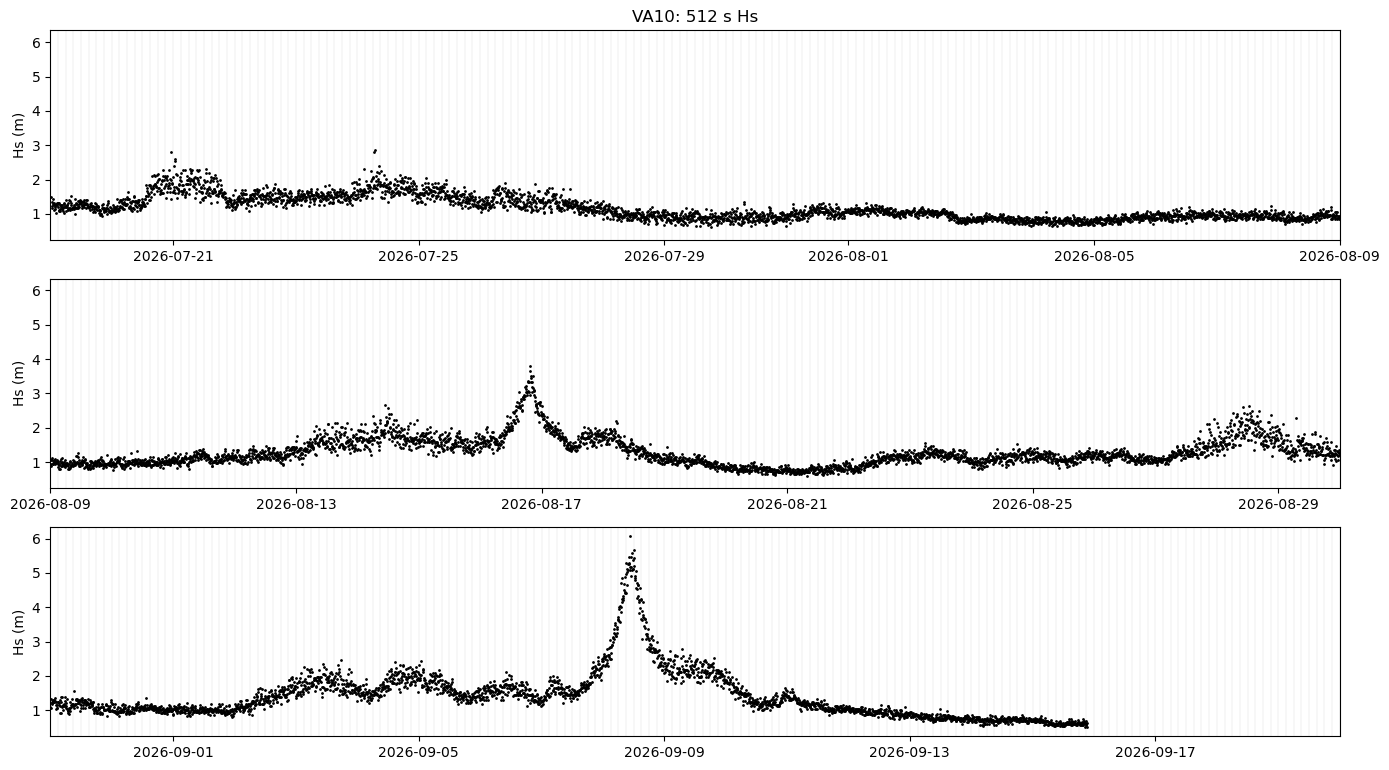

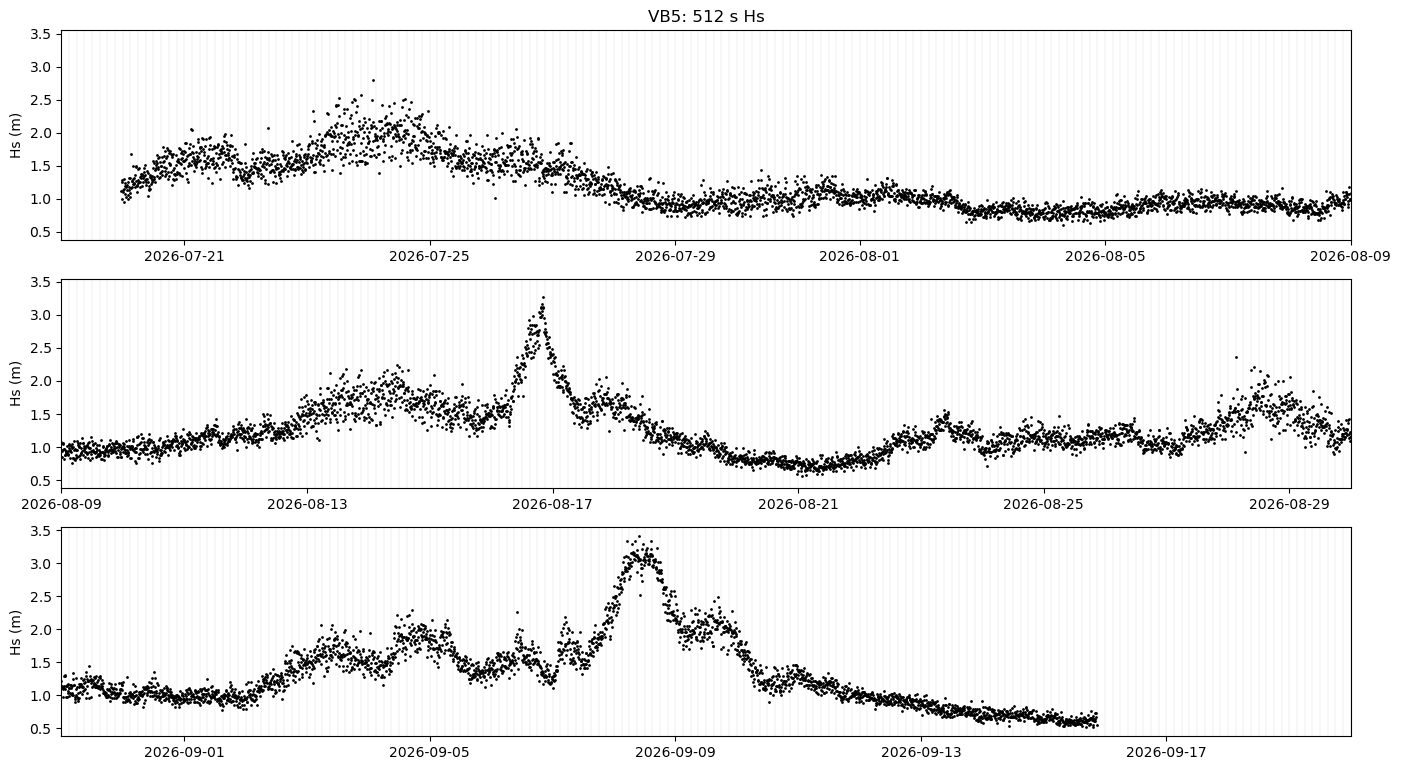

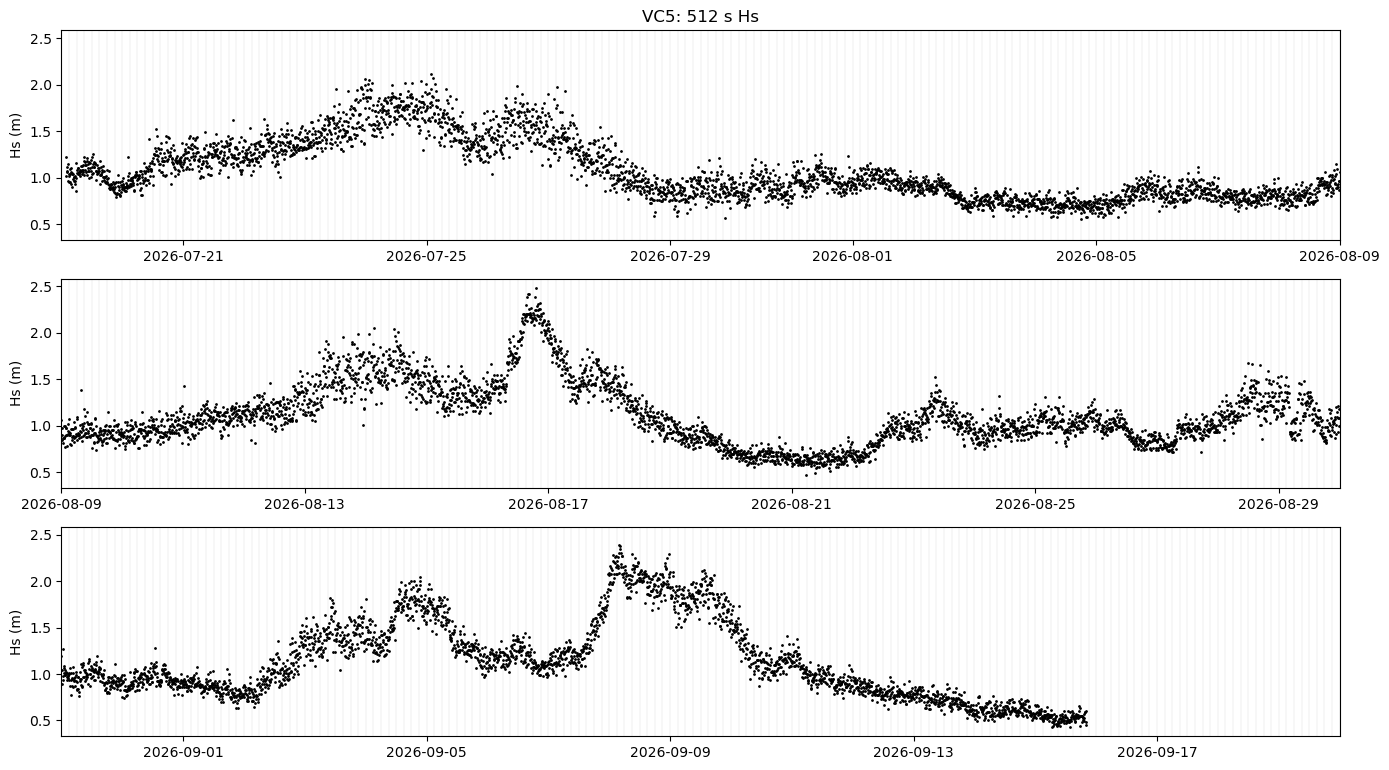

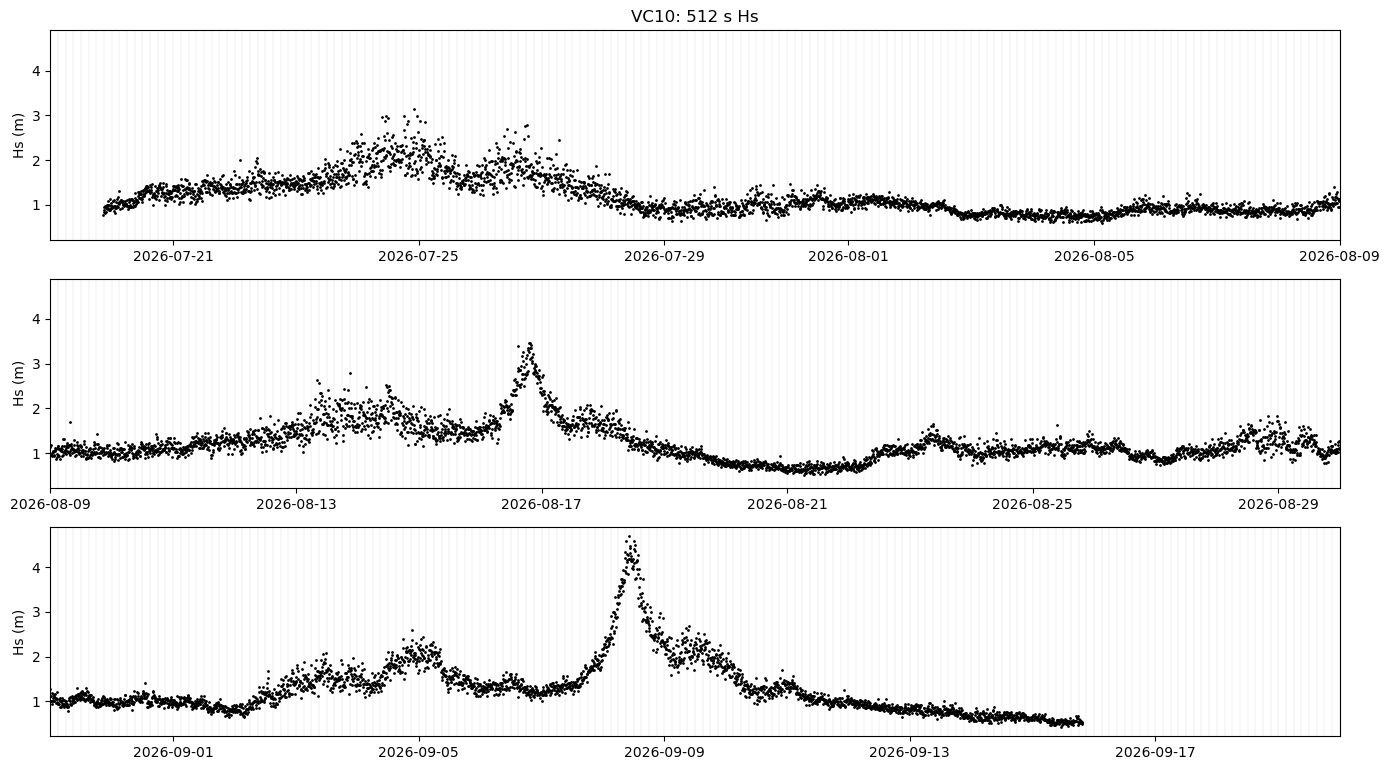

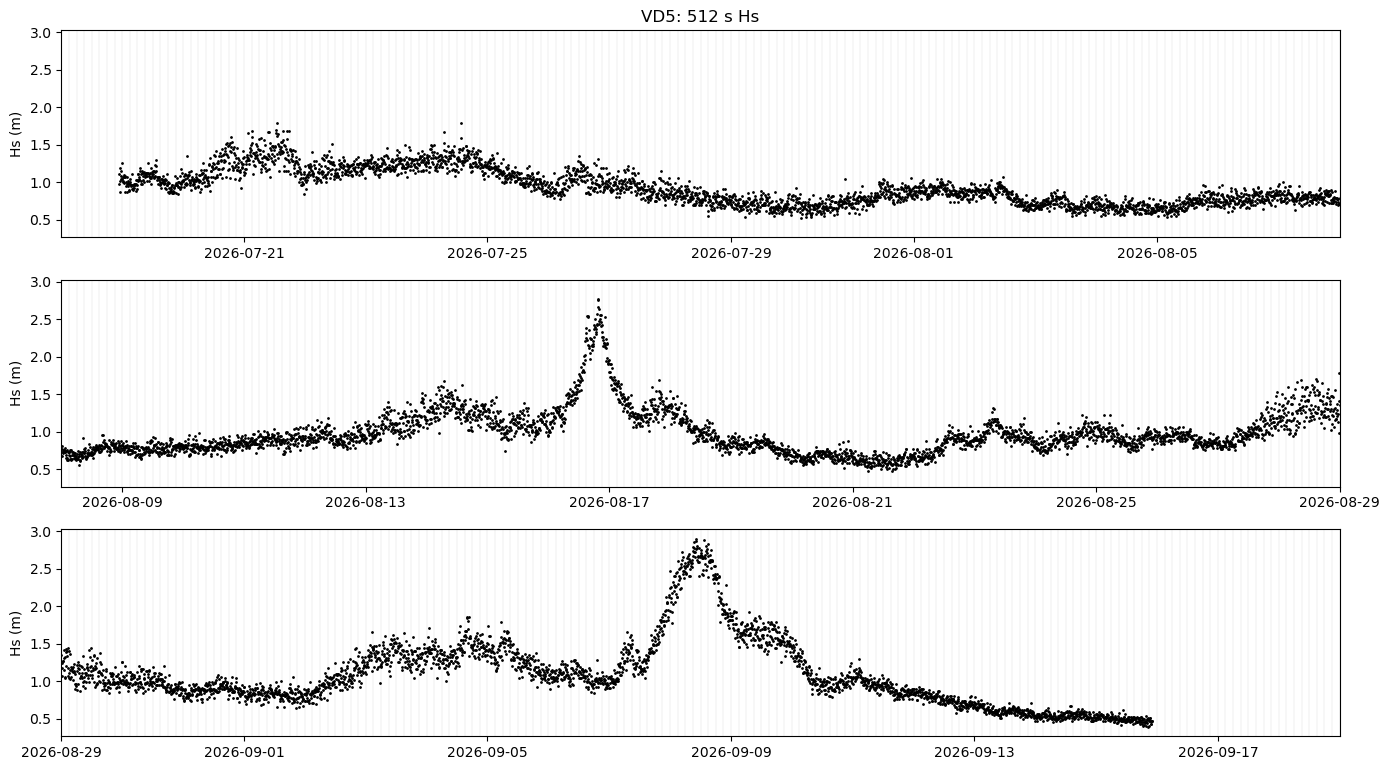

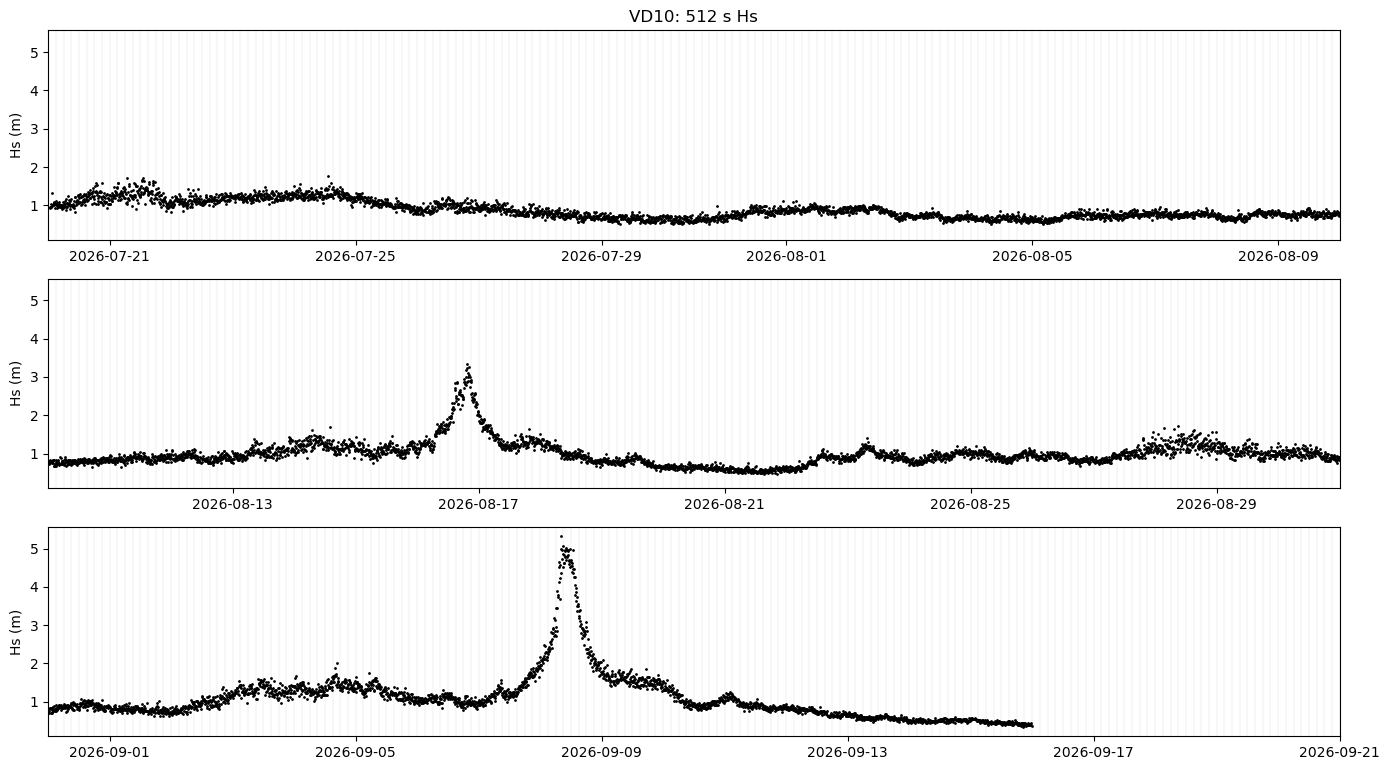

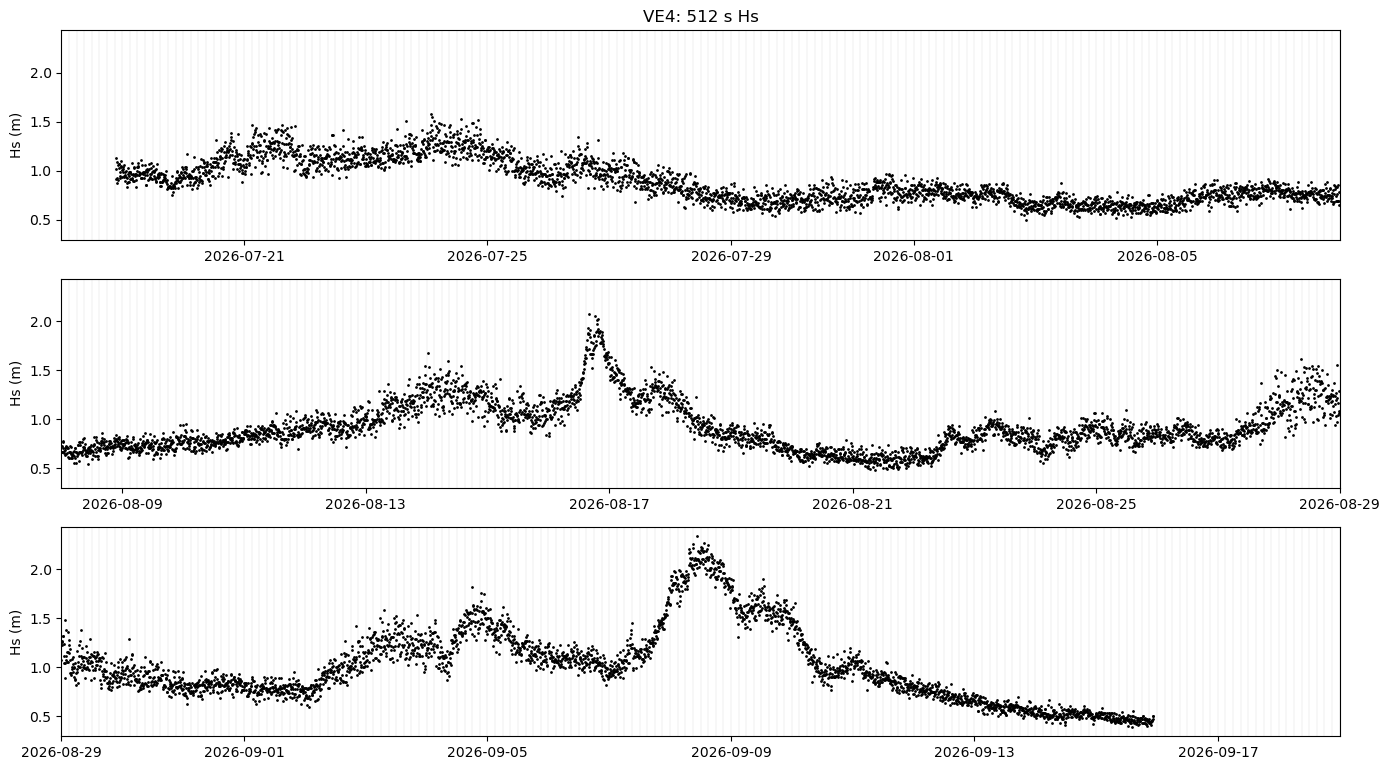

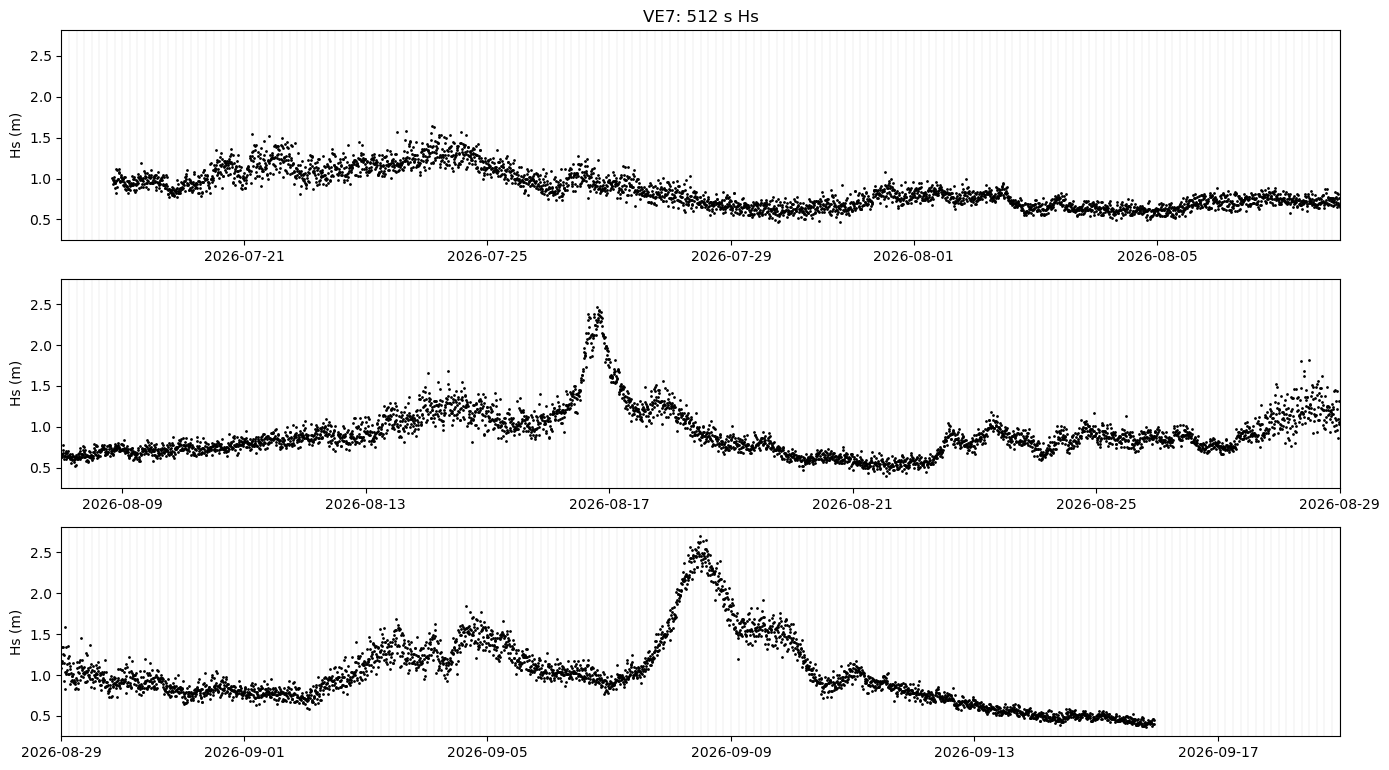

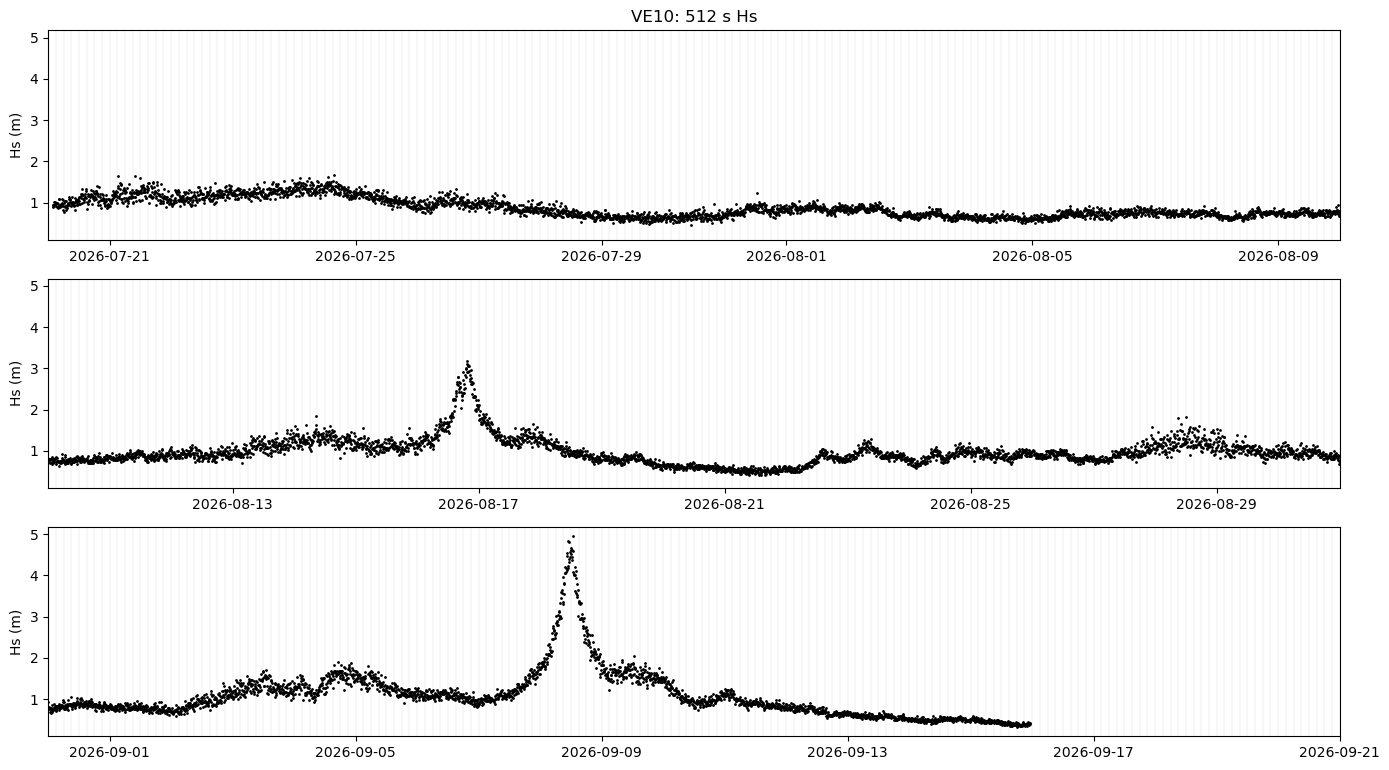

In [6]:
for S in SENSORS:
    plot_var(bulk[S], 'Hs', S, 'Hs (m)')

### Cross-shore velocity u (+ onshore)

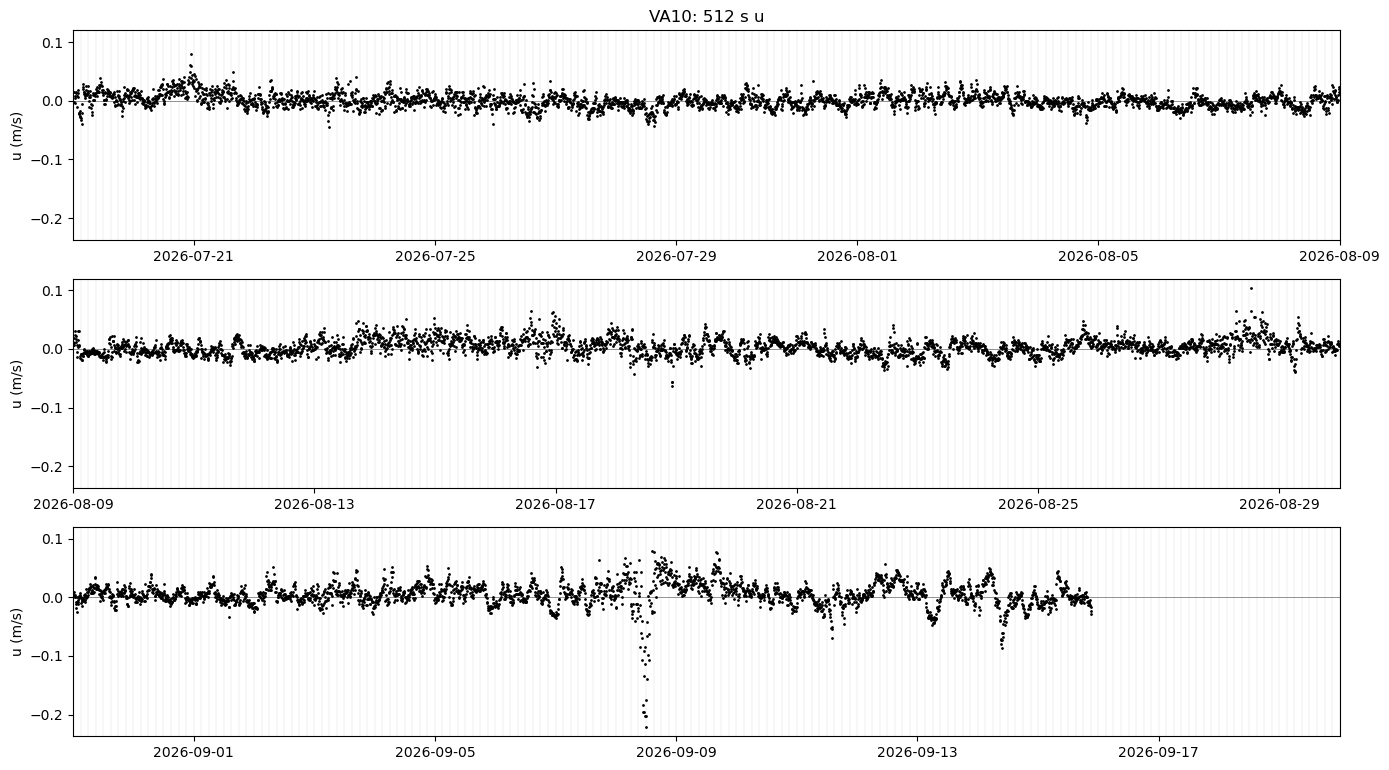

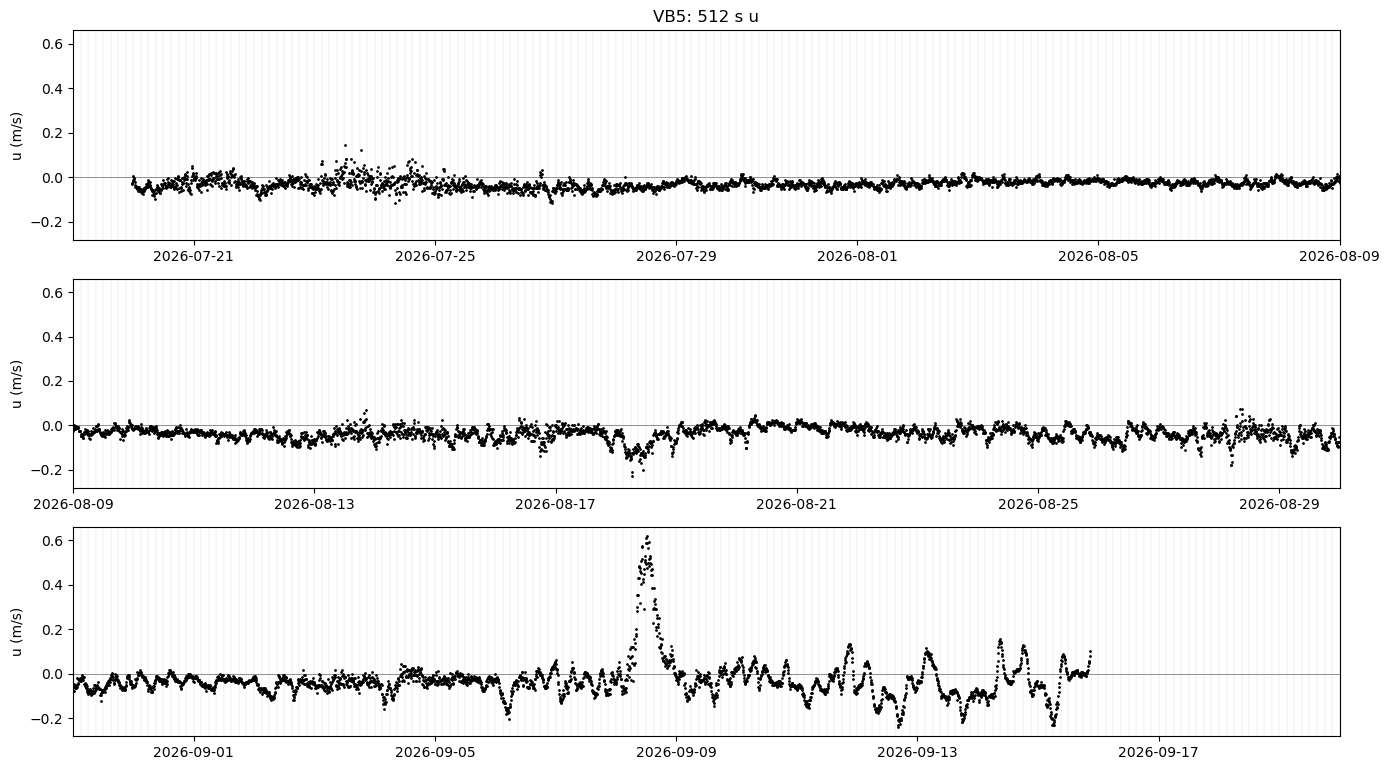

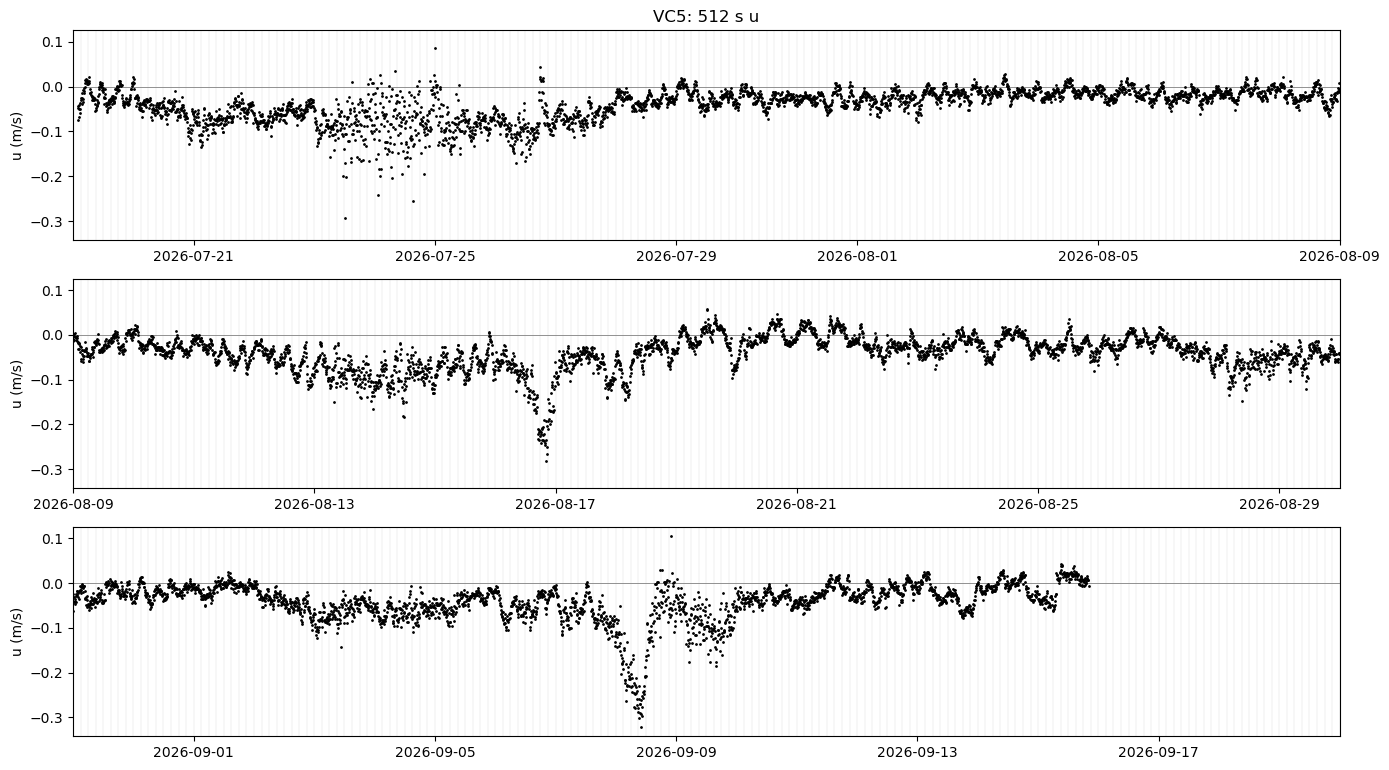

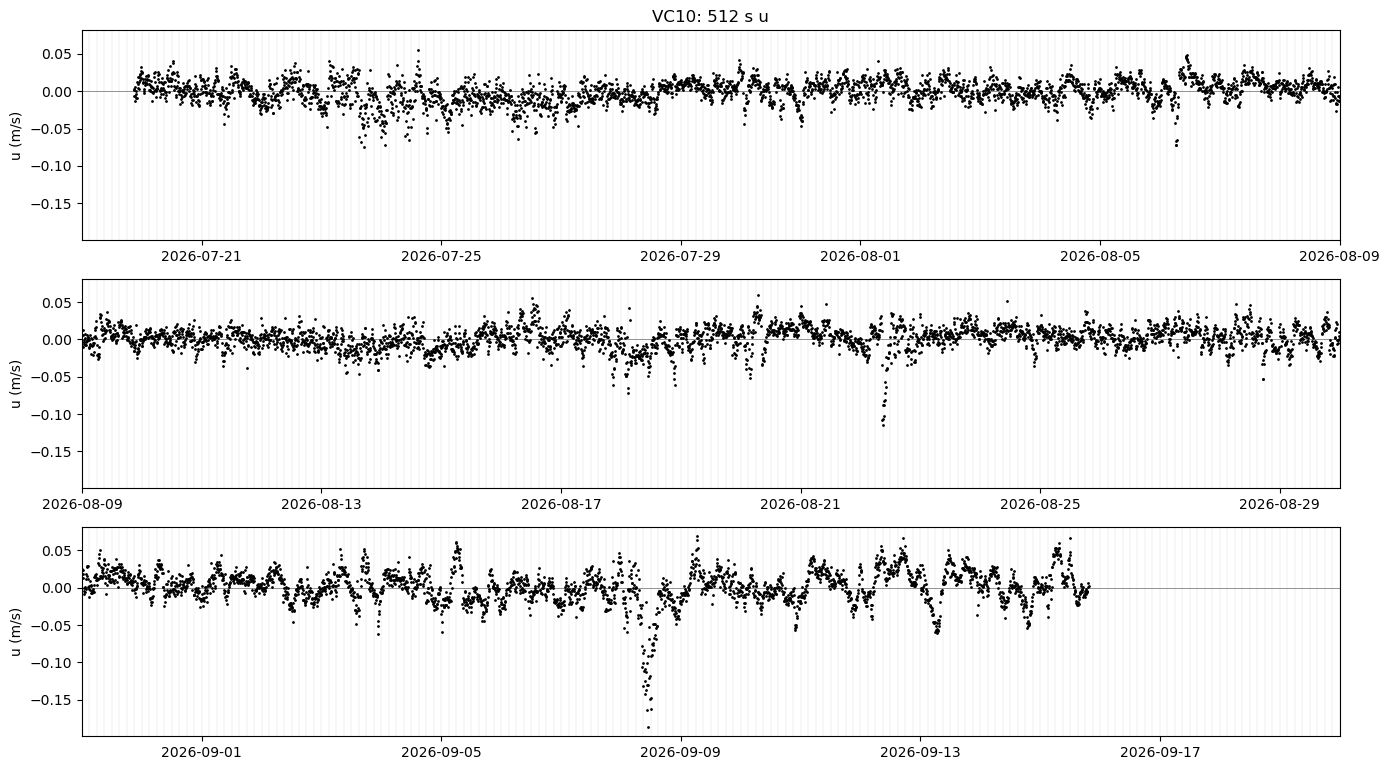

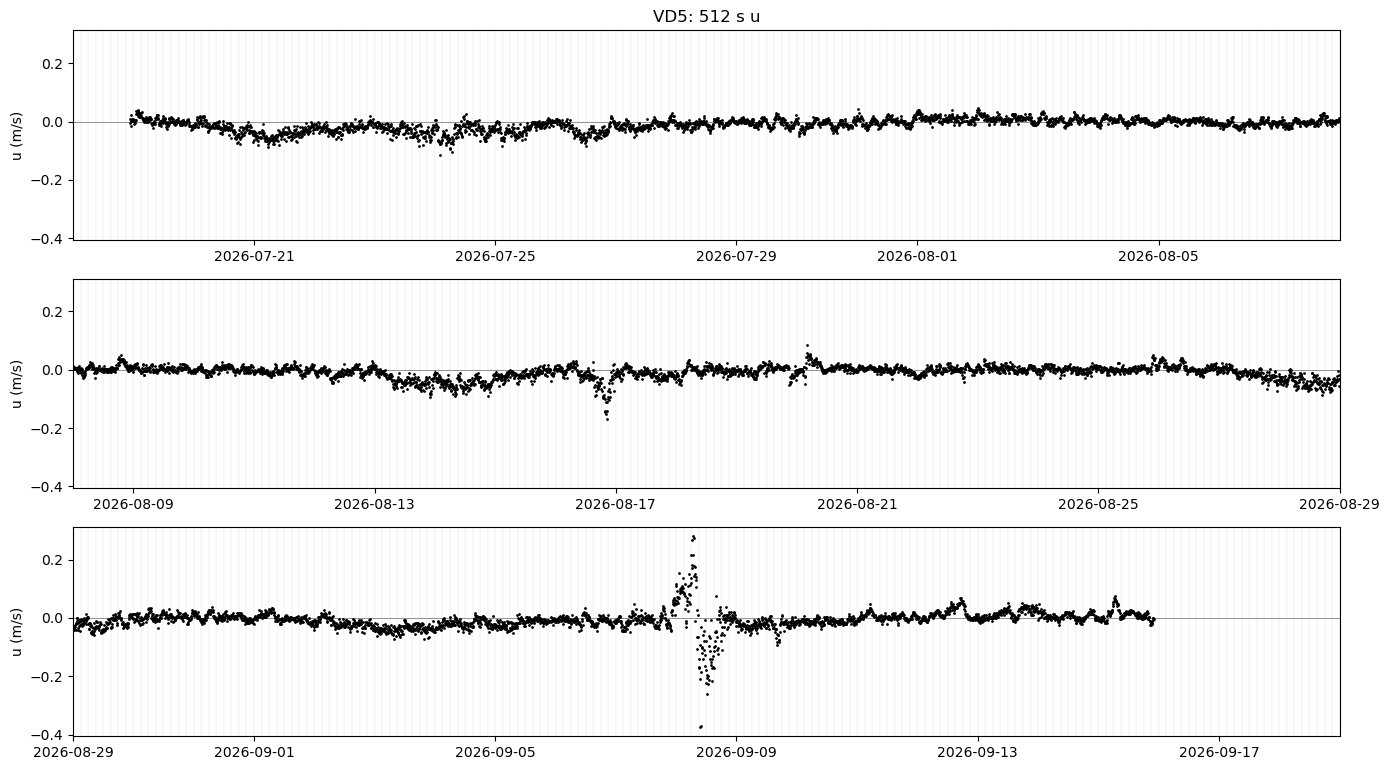

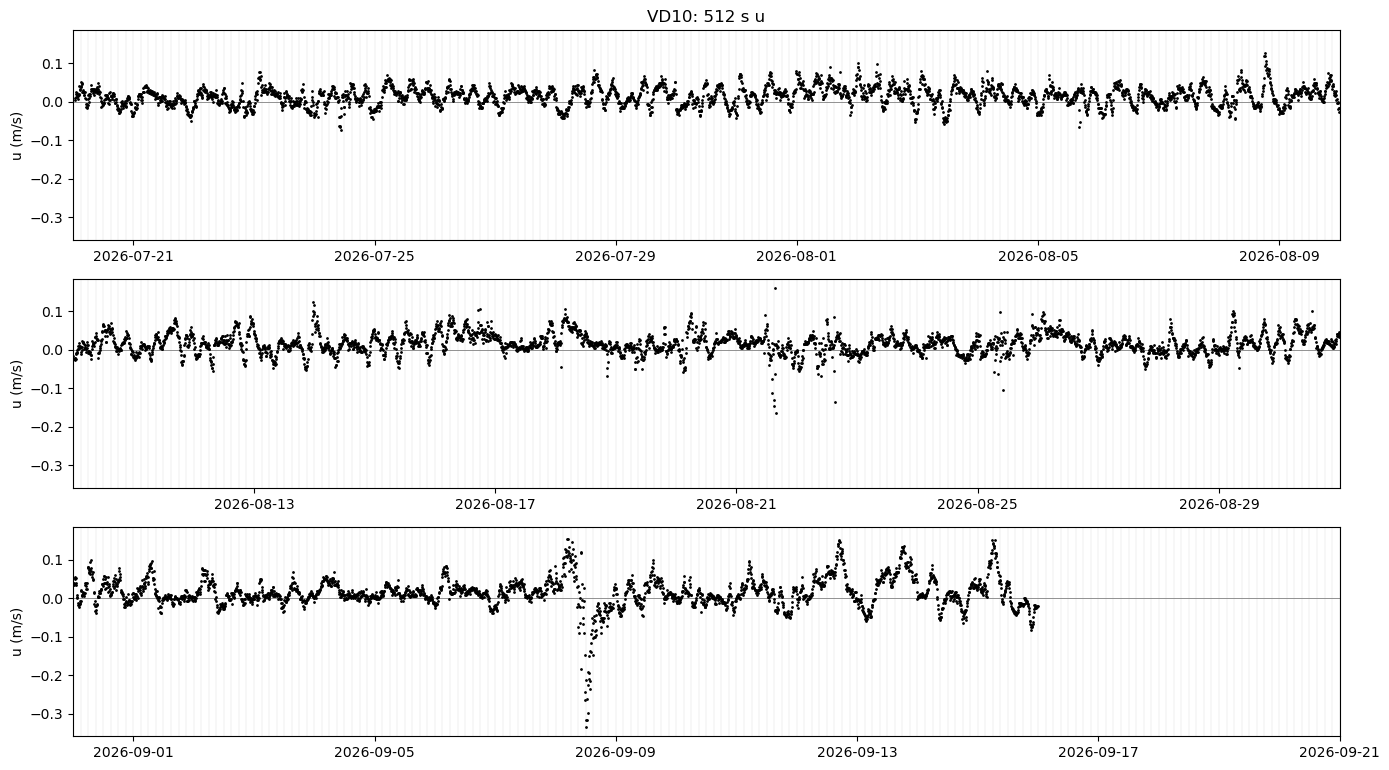

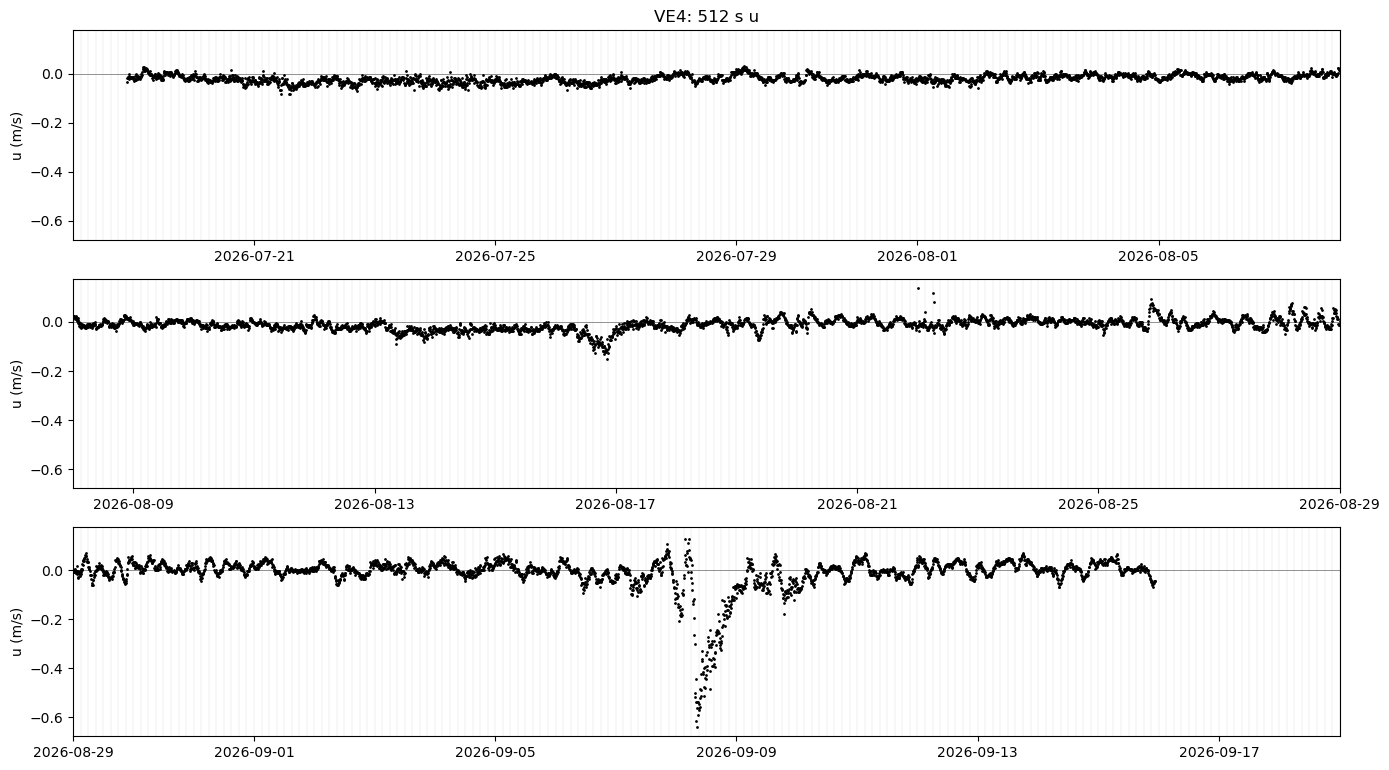

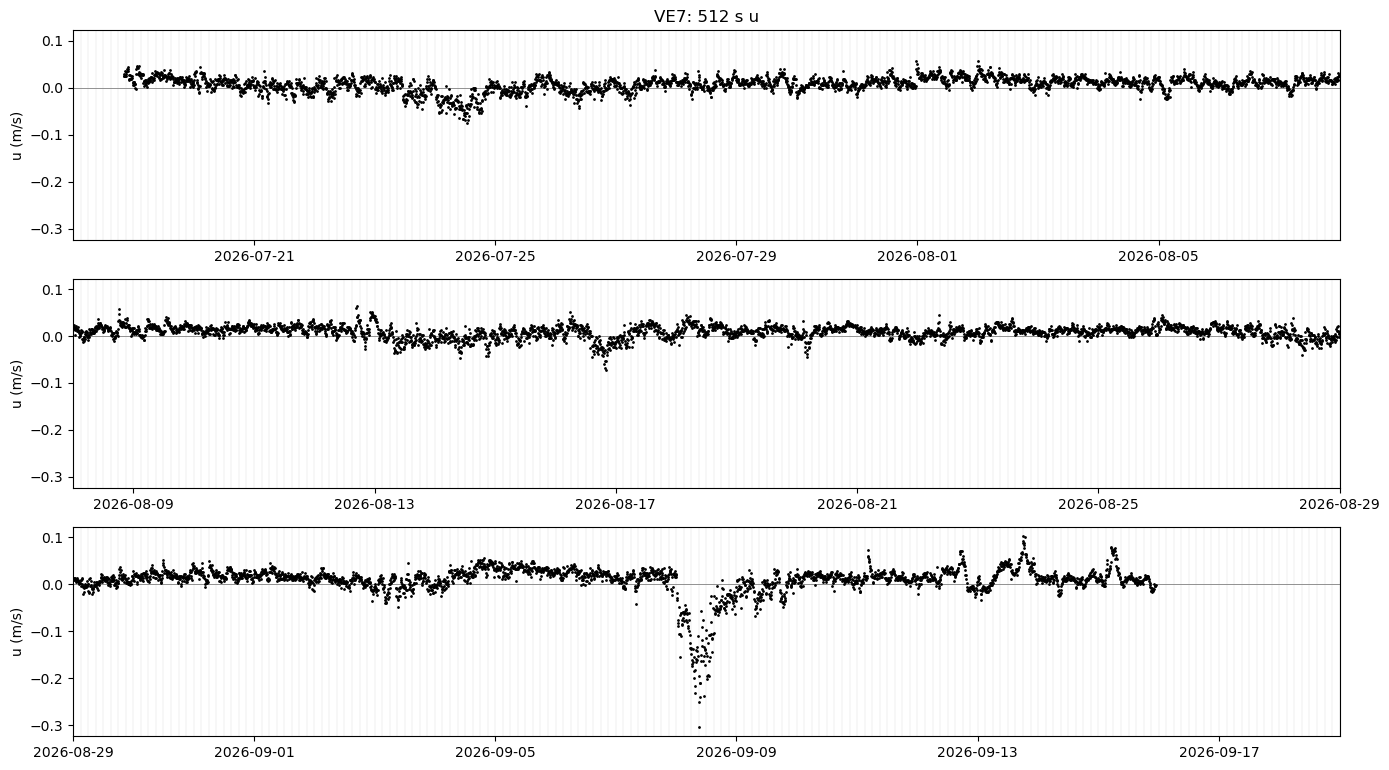

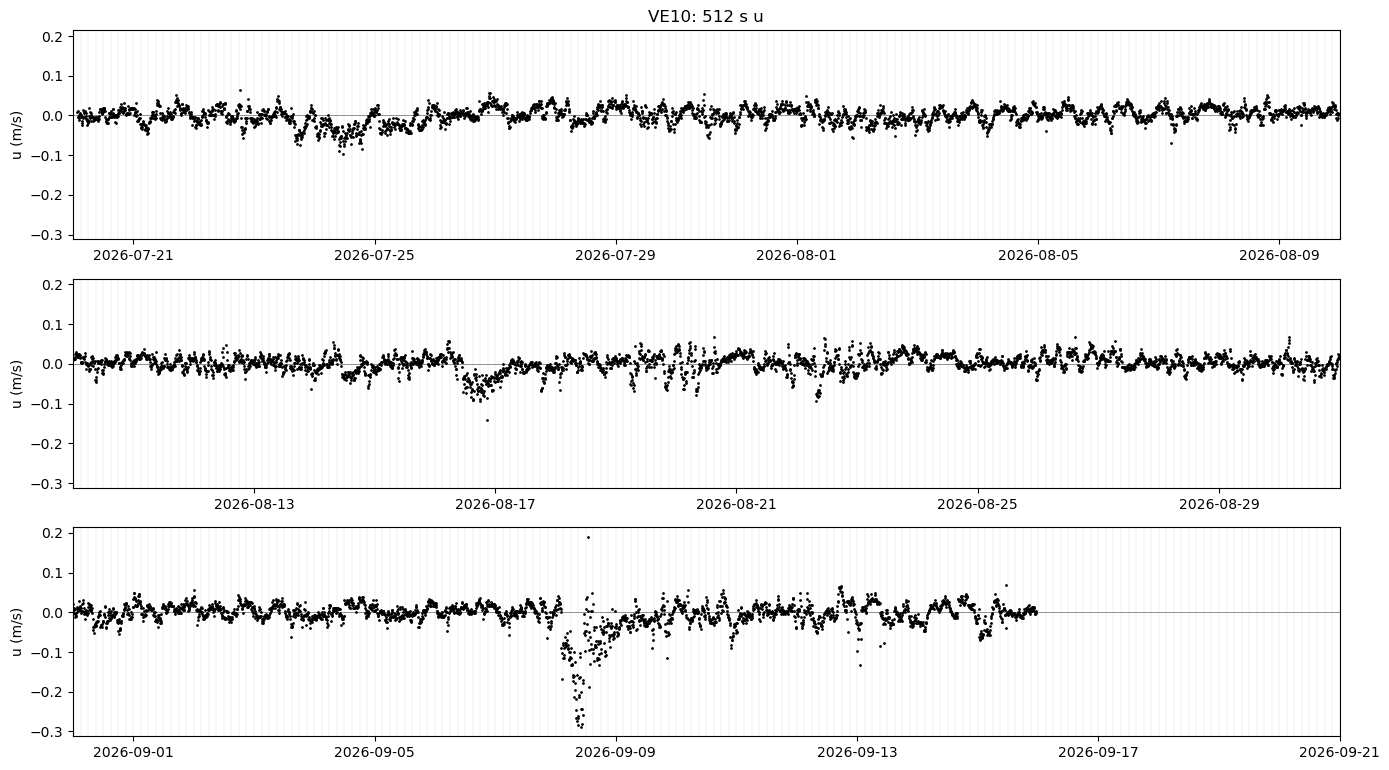

In [7]:
for S in SENSORS:
    plot_var(bulk[S], 'u', S, 'u (m/s)')

### Alongshore velocity v

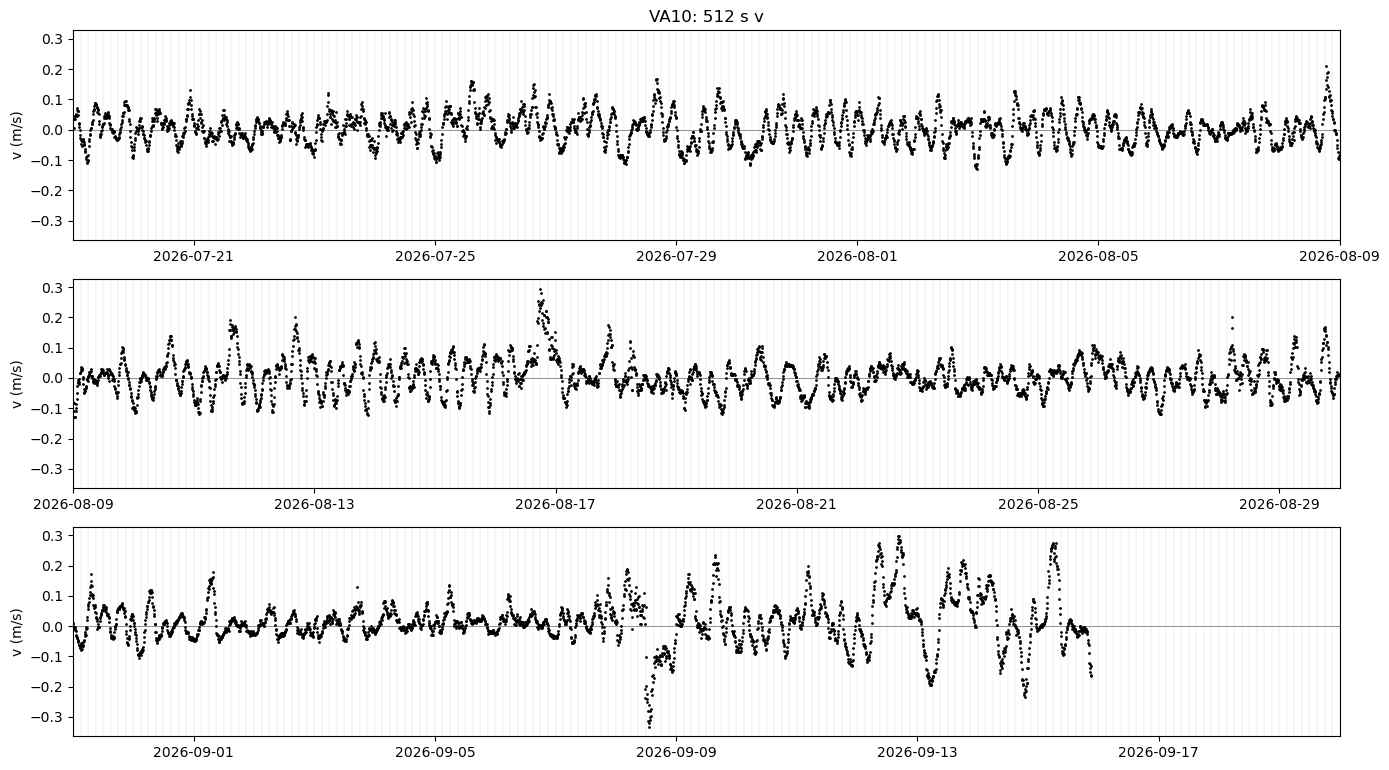

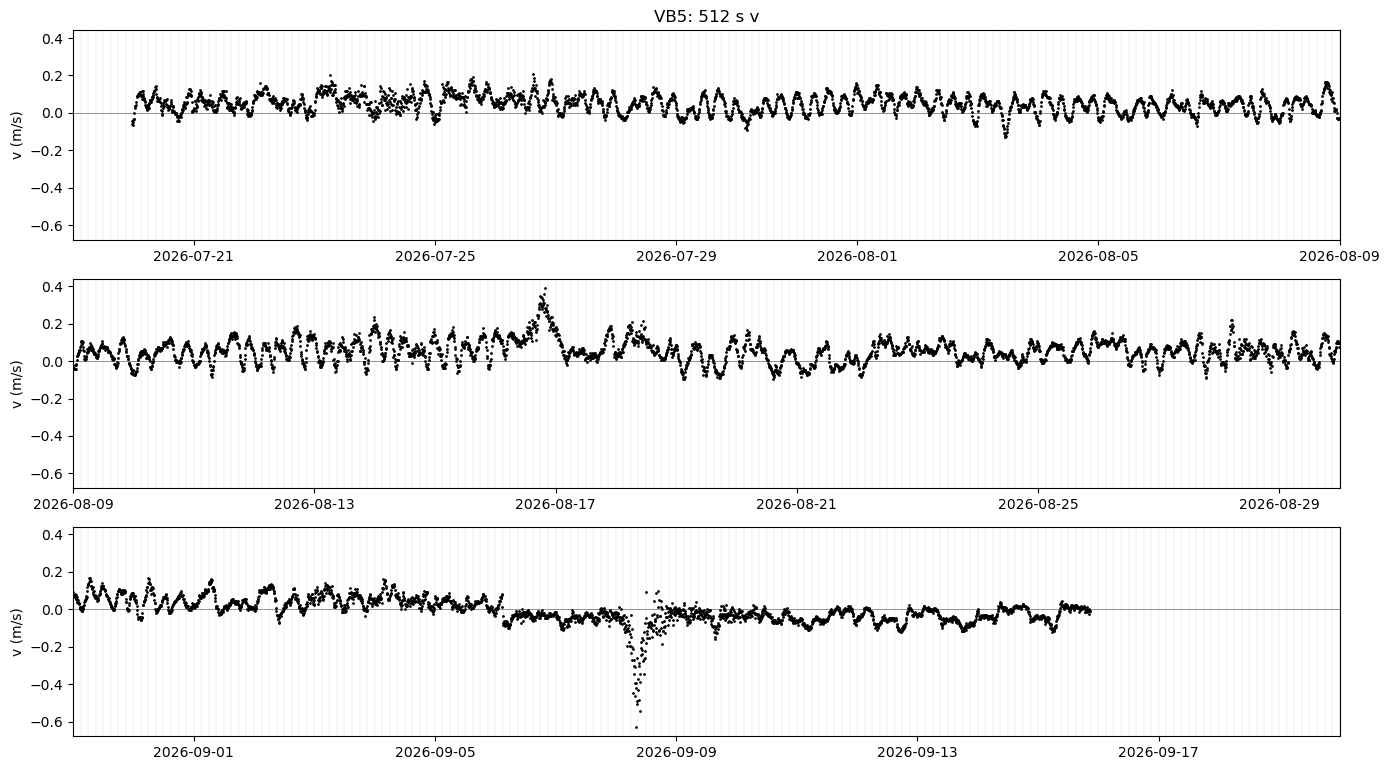

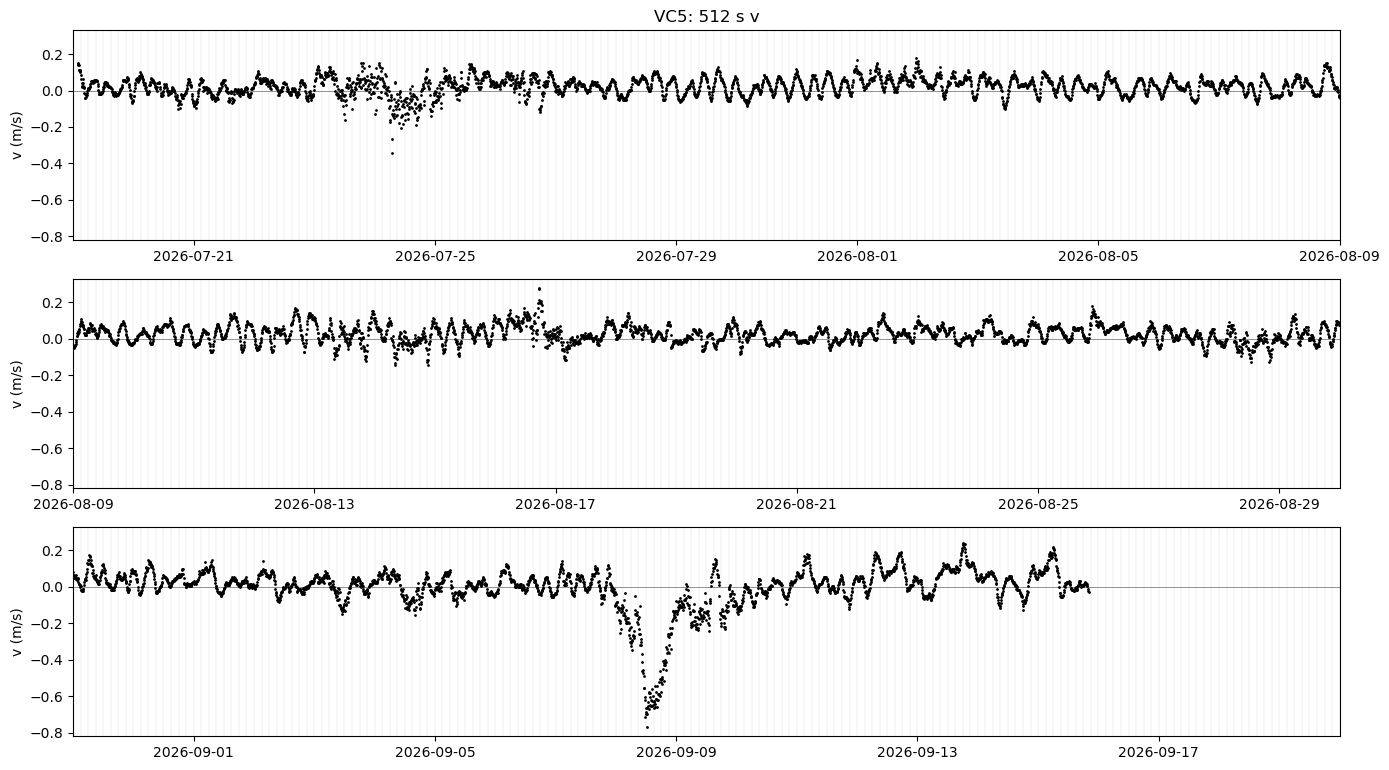

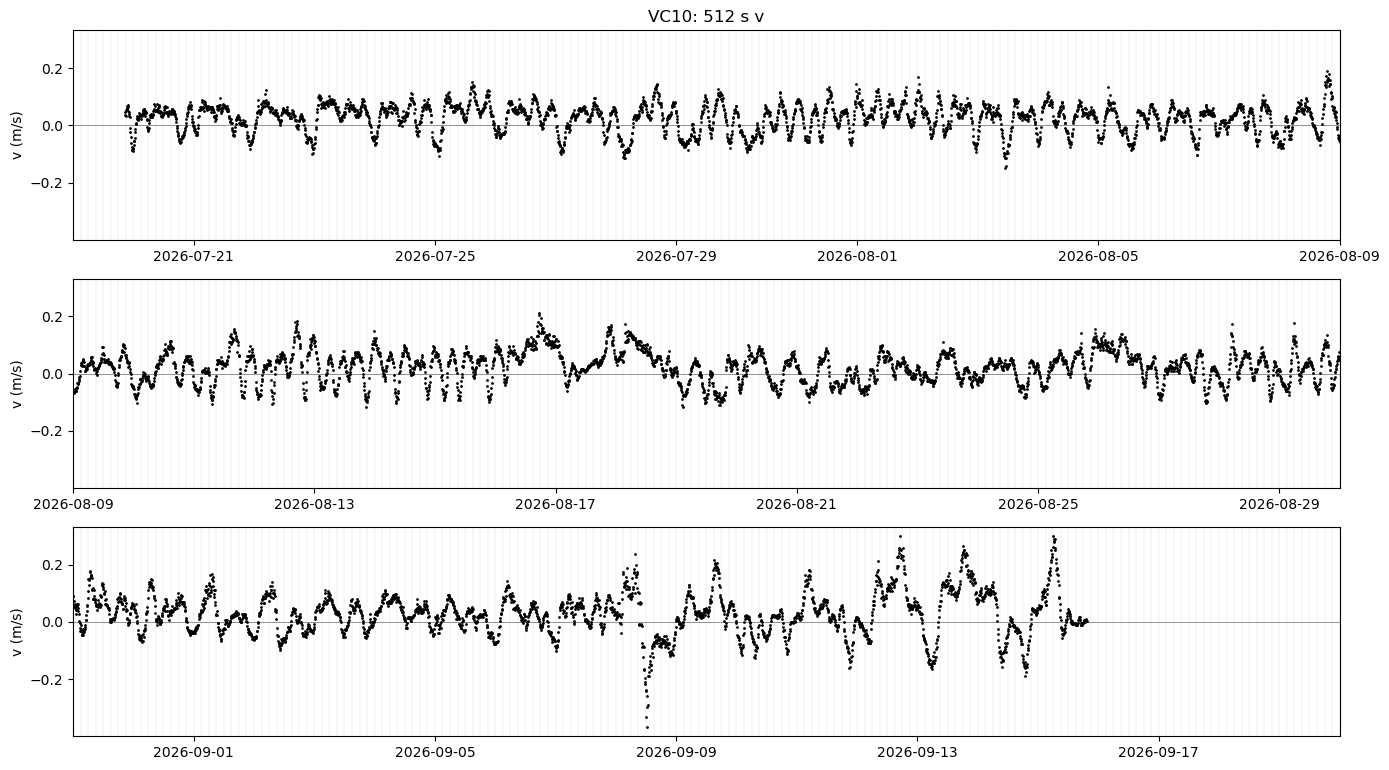

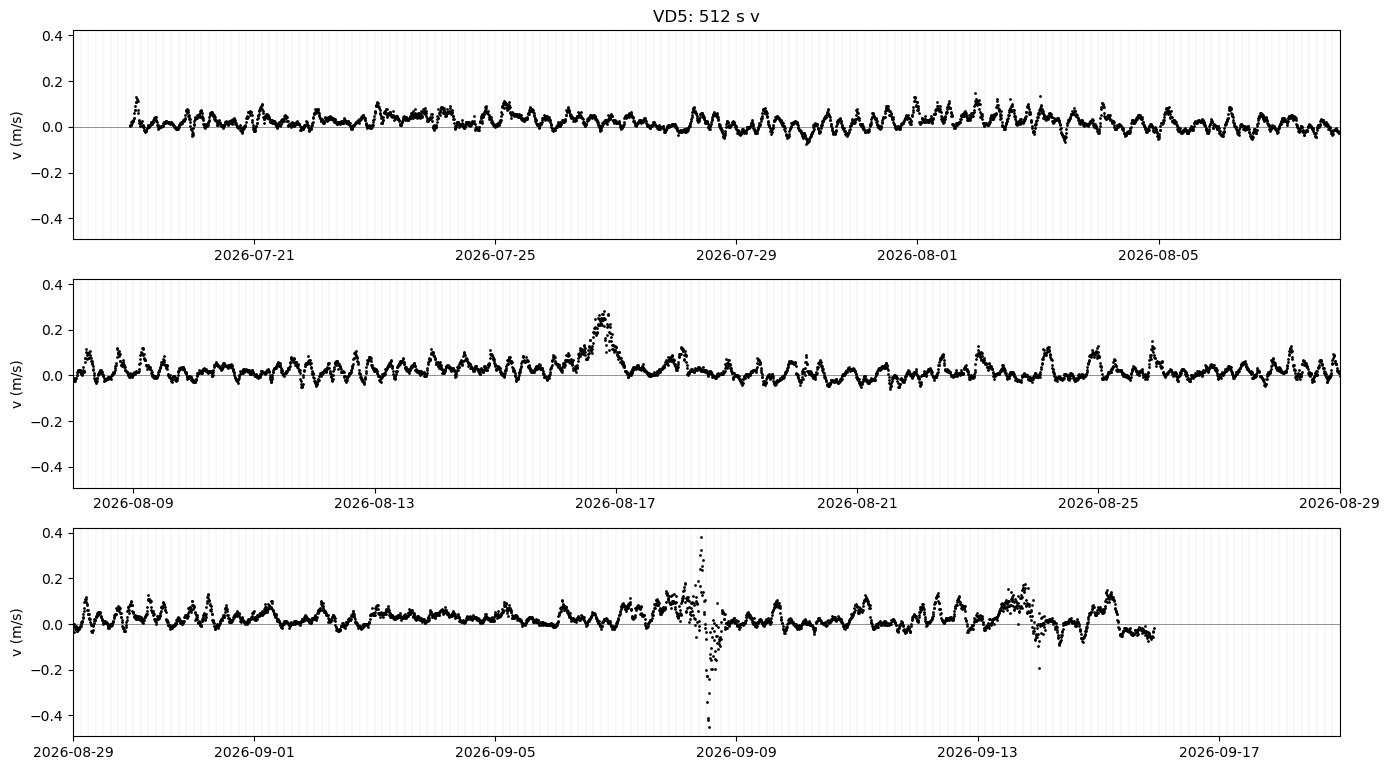

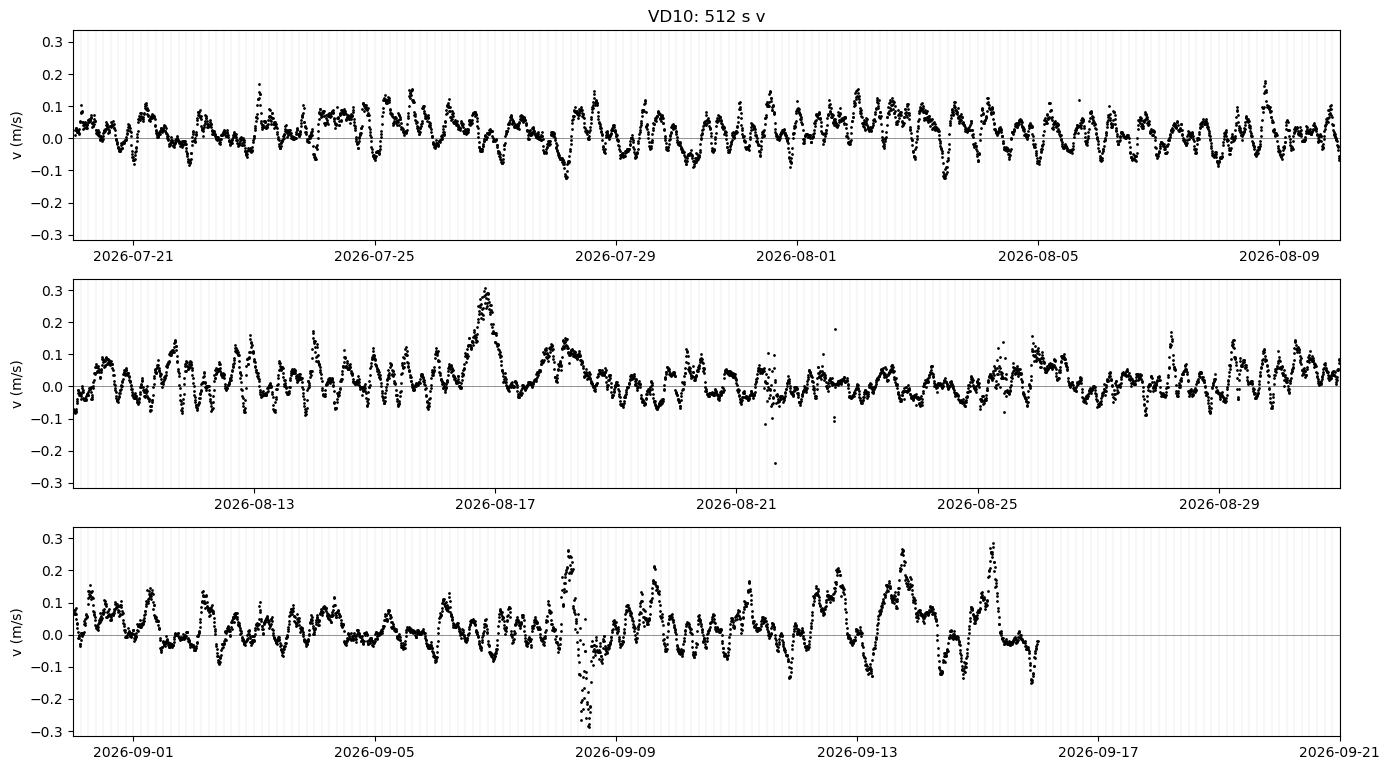

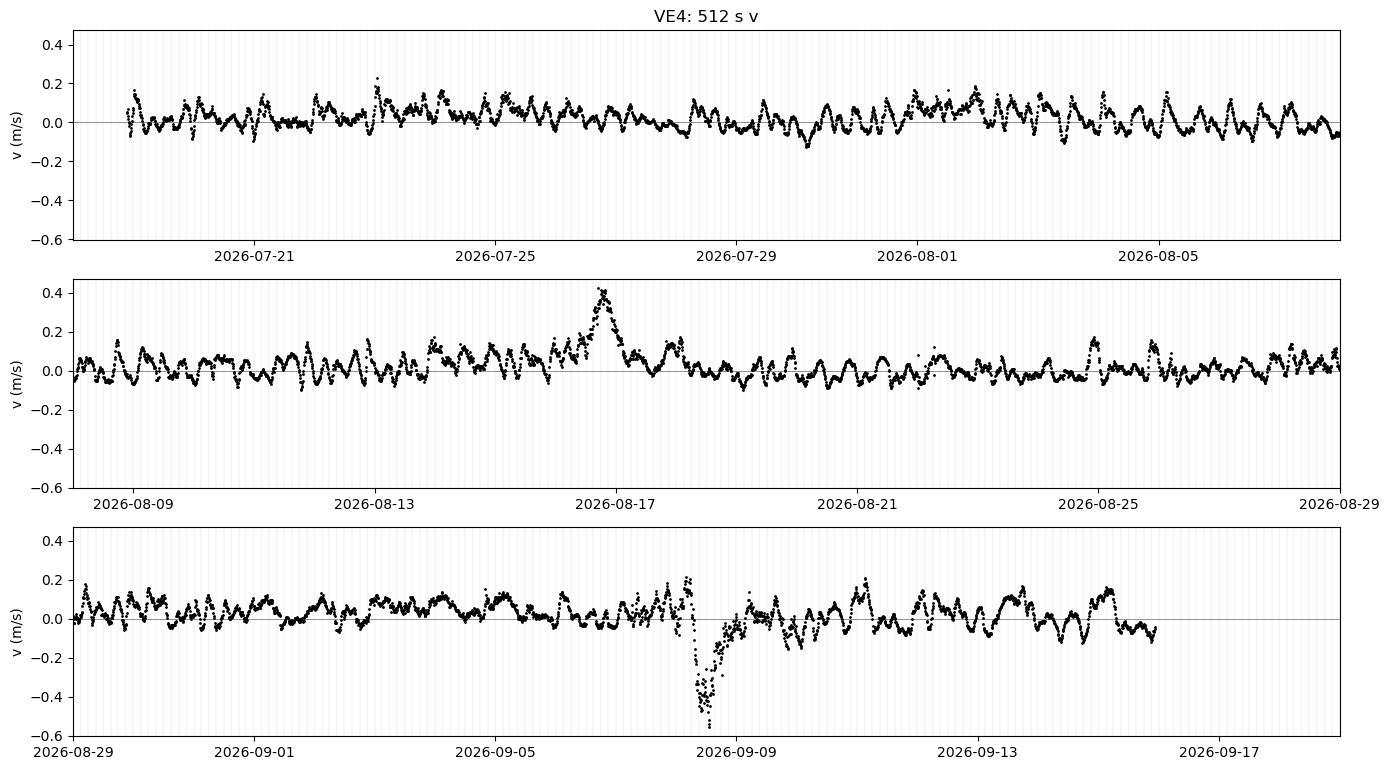

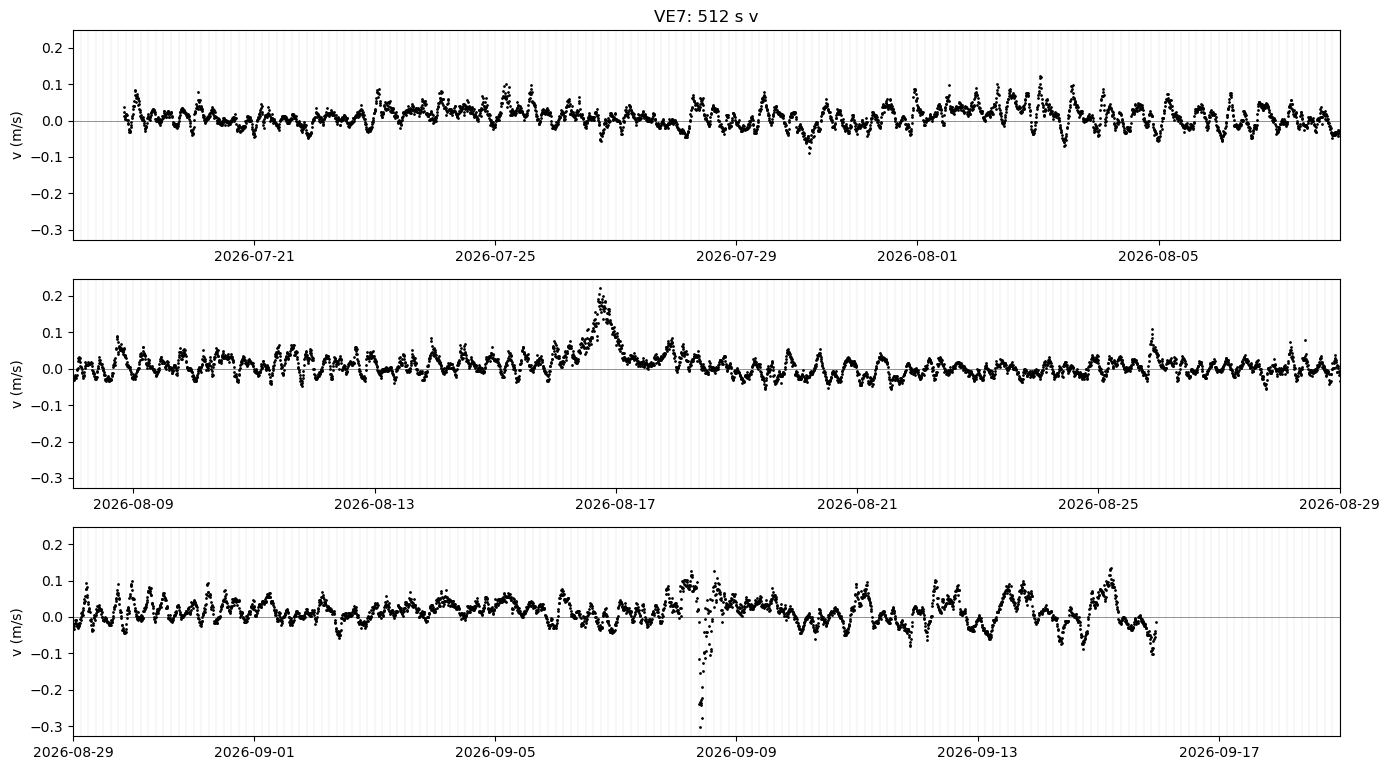

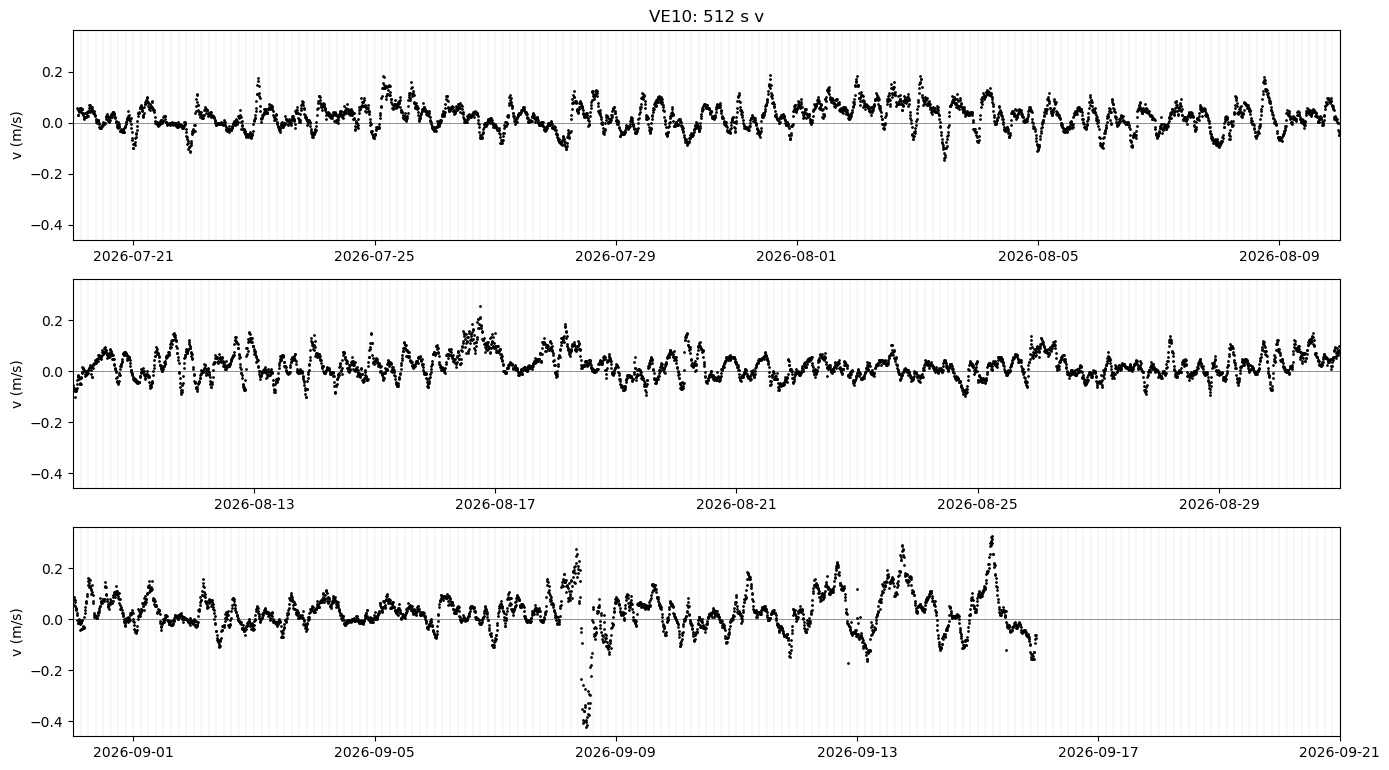

In [8]:
for S in SENSORS:
    plot_var(bulk[S], 'v', S, 'v (m/s)')

### Current direction (toward, deg true)
Noisy whenever the mean current is weak; that scatter is real, not bad data.

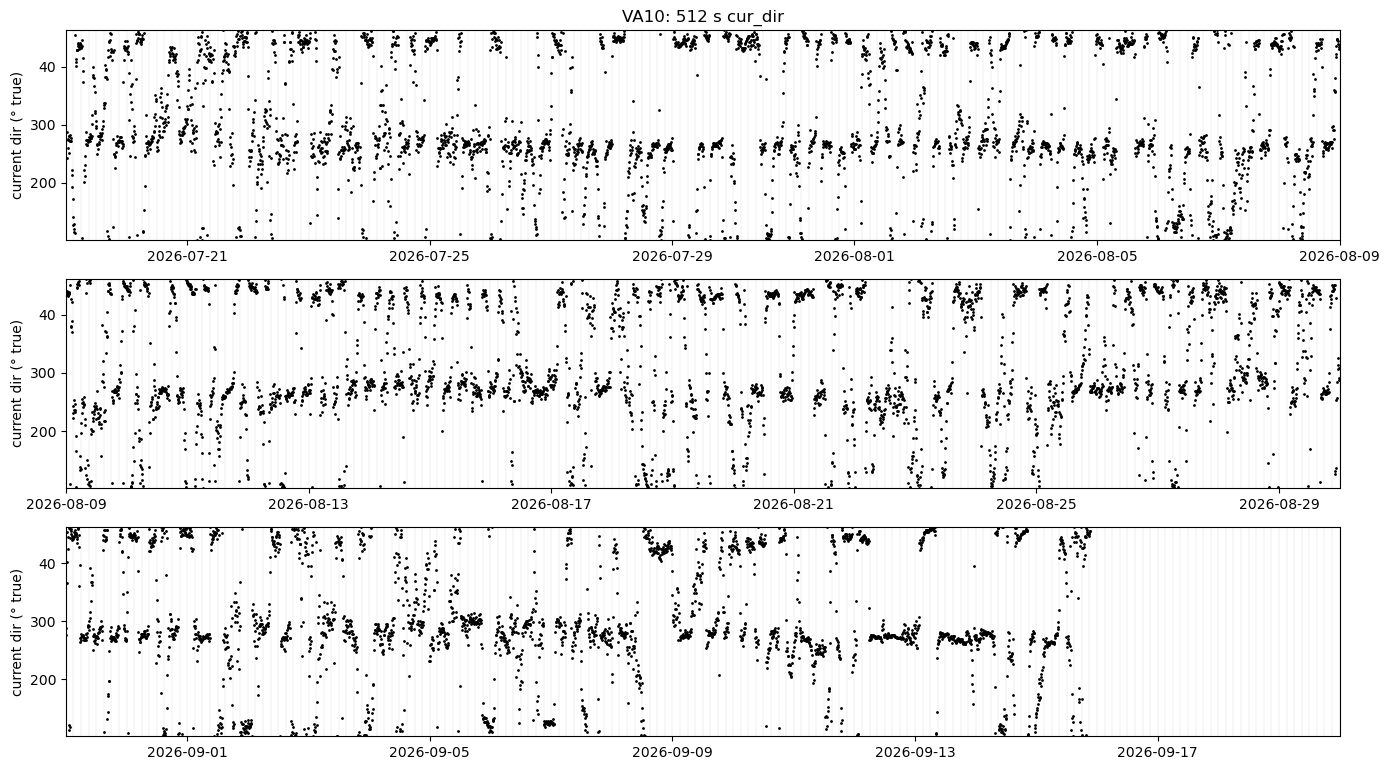

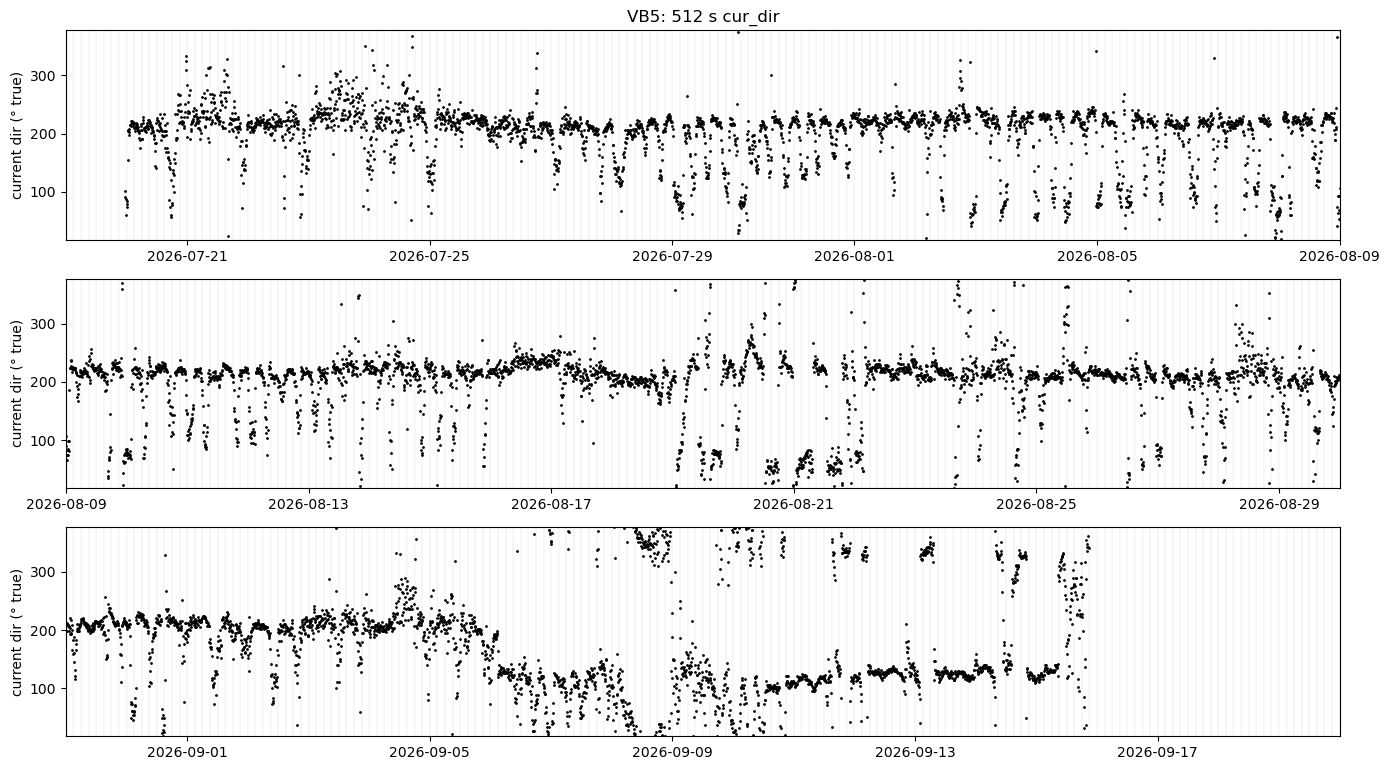

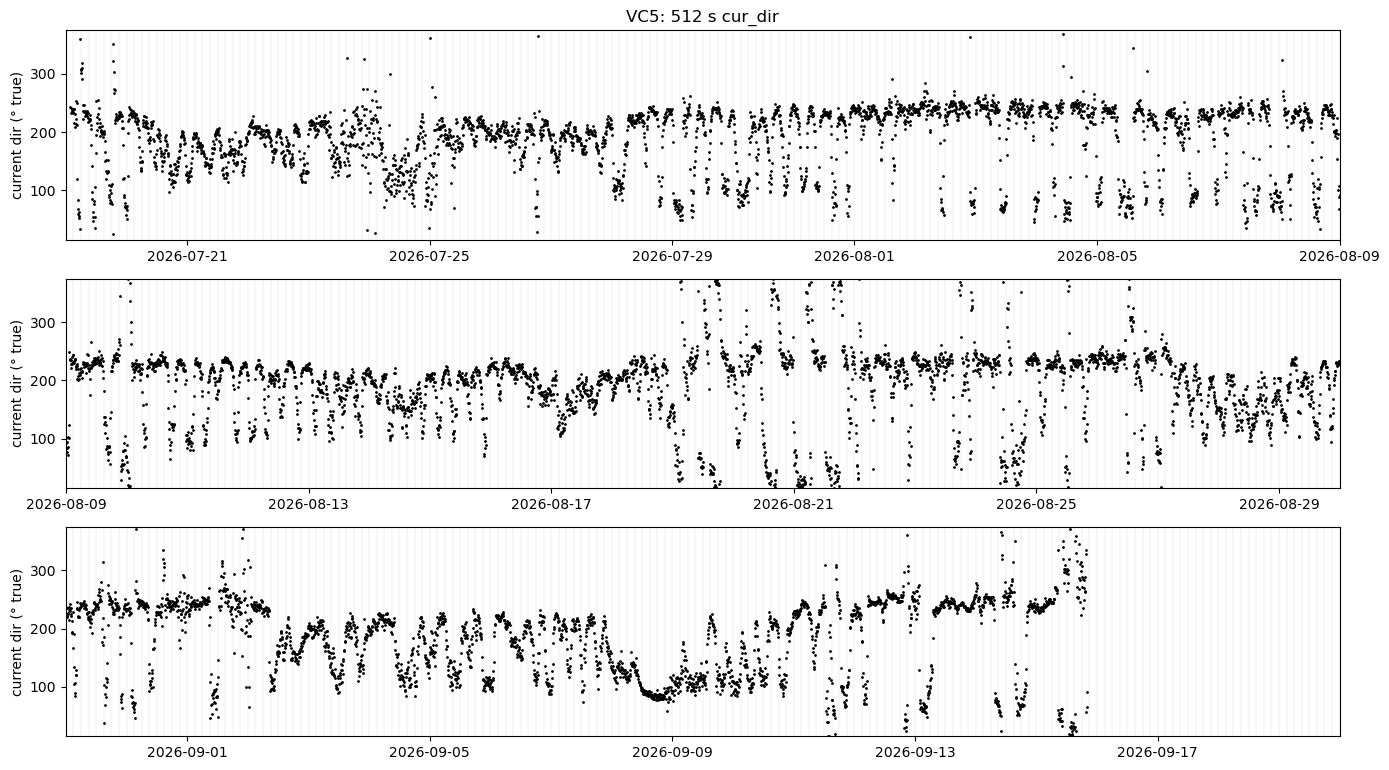

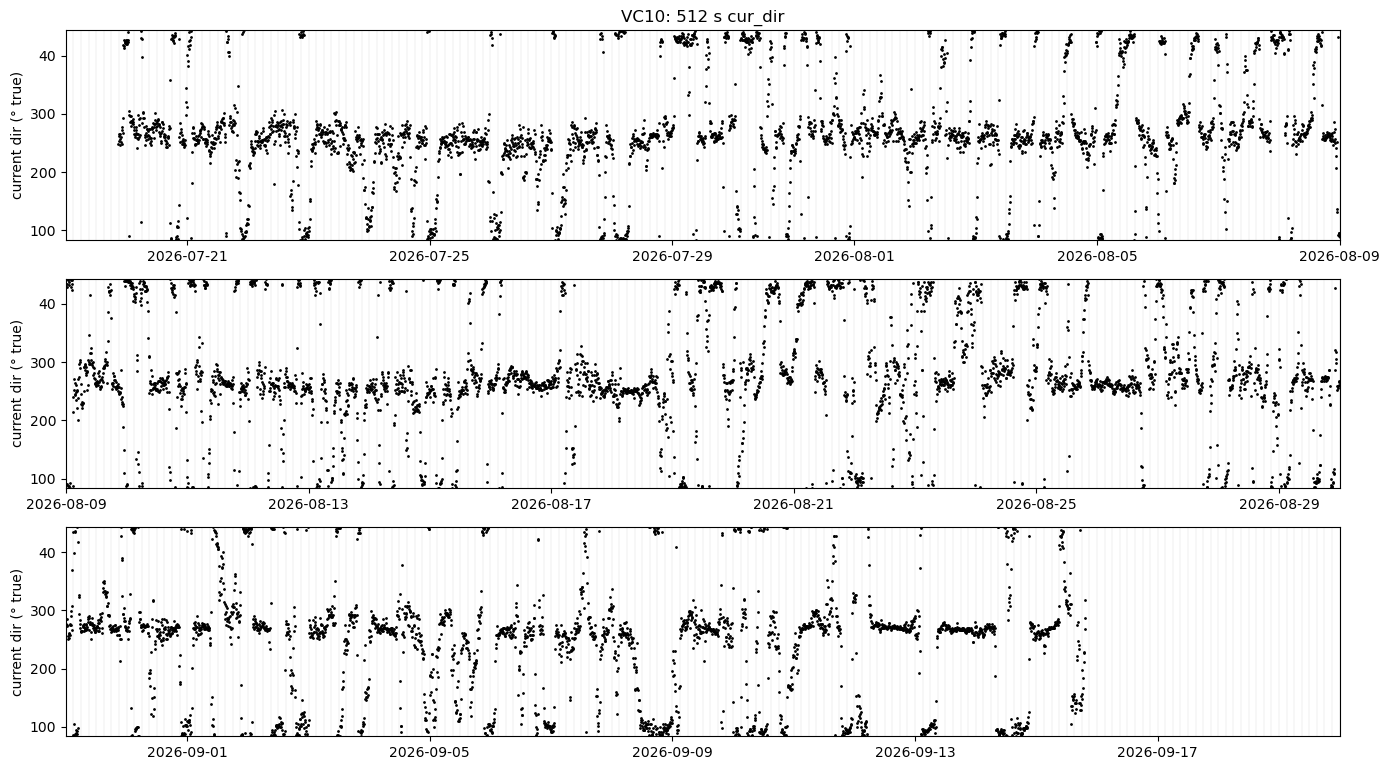

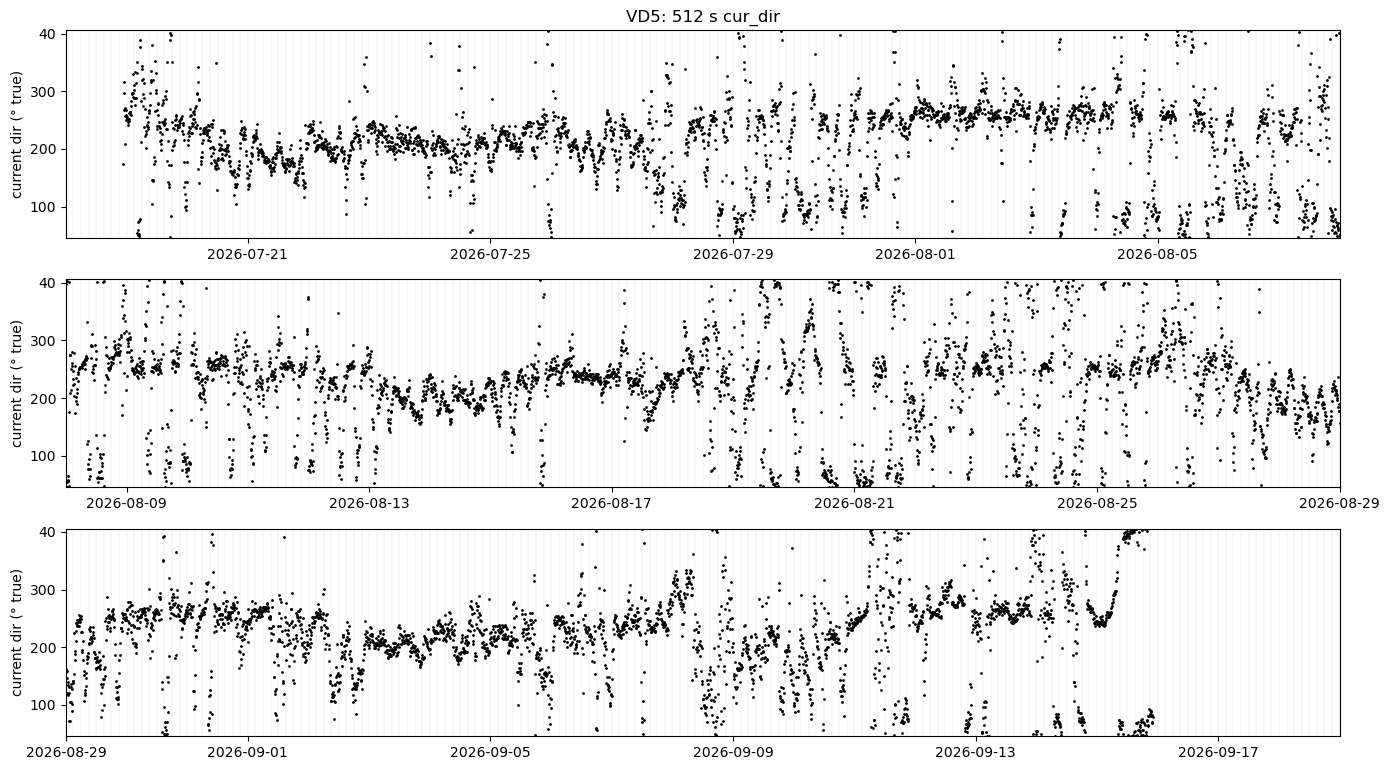

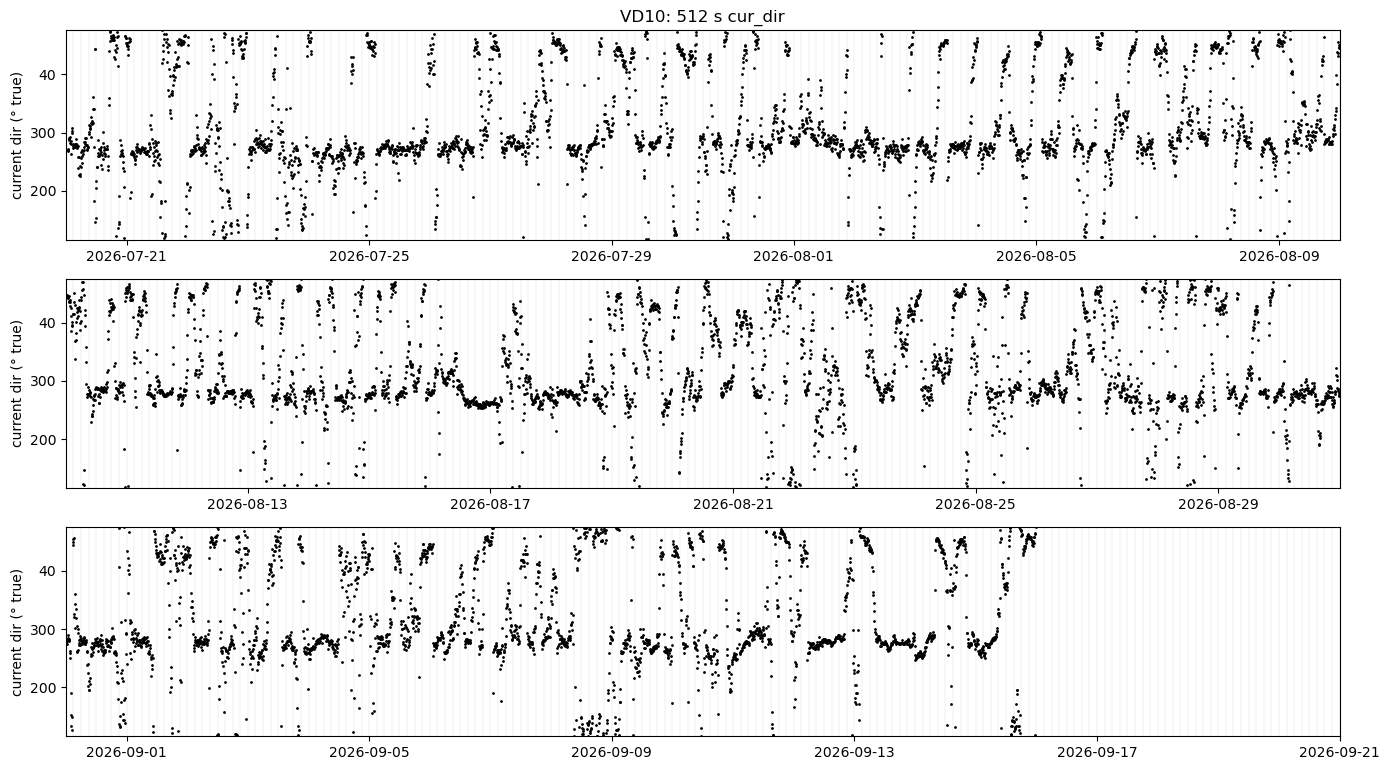

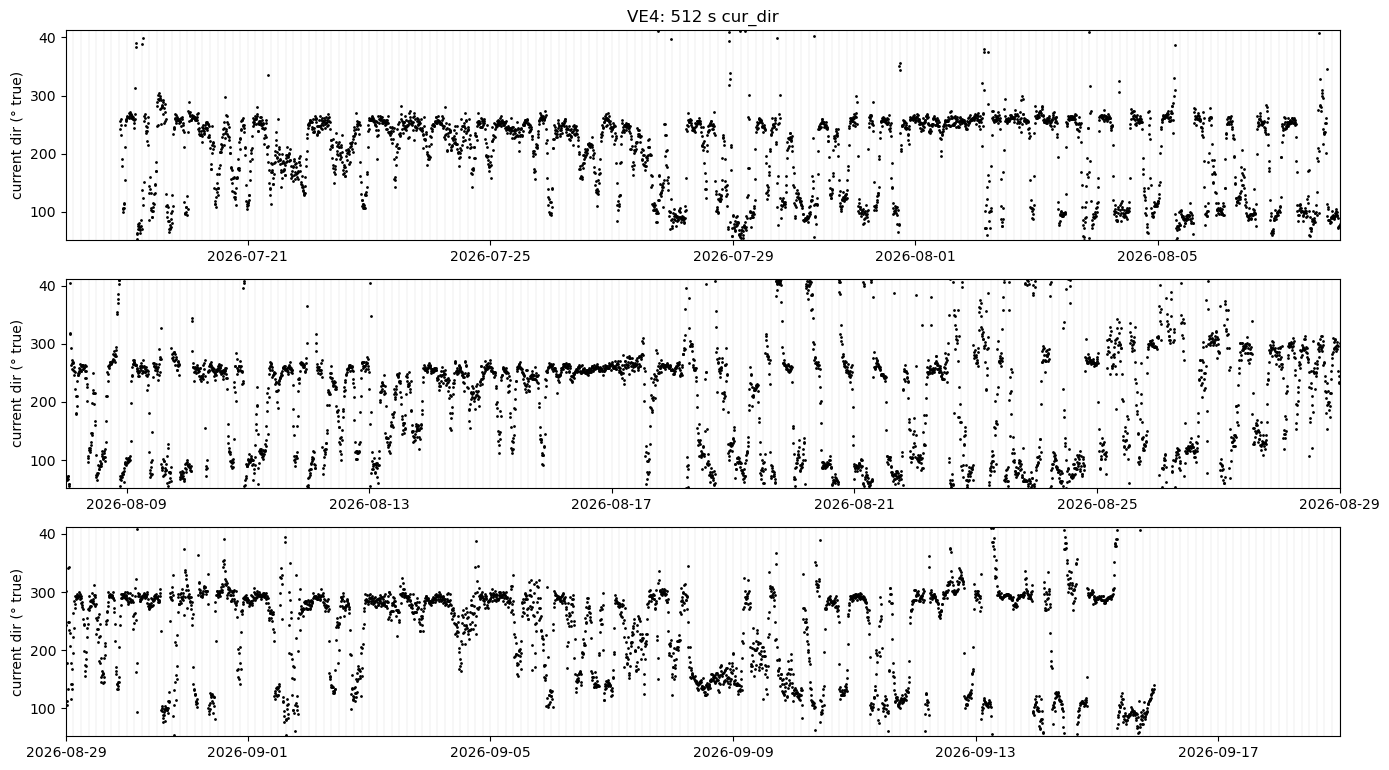

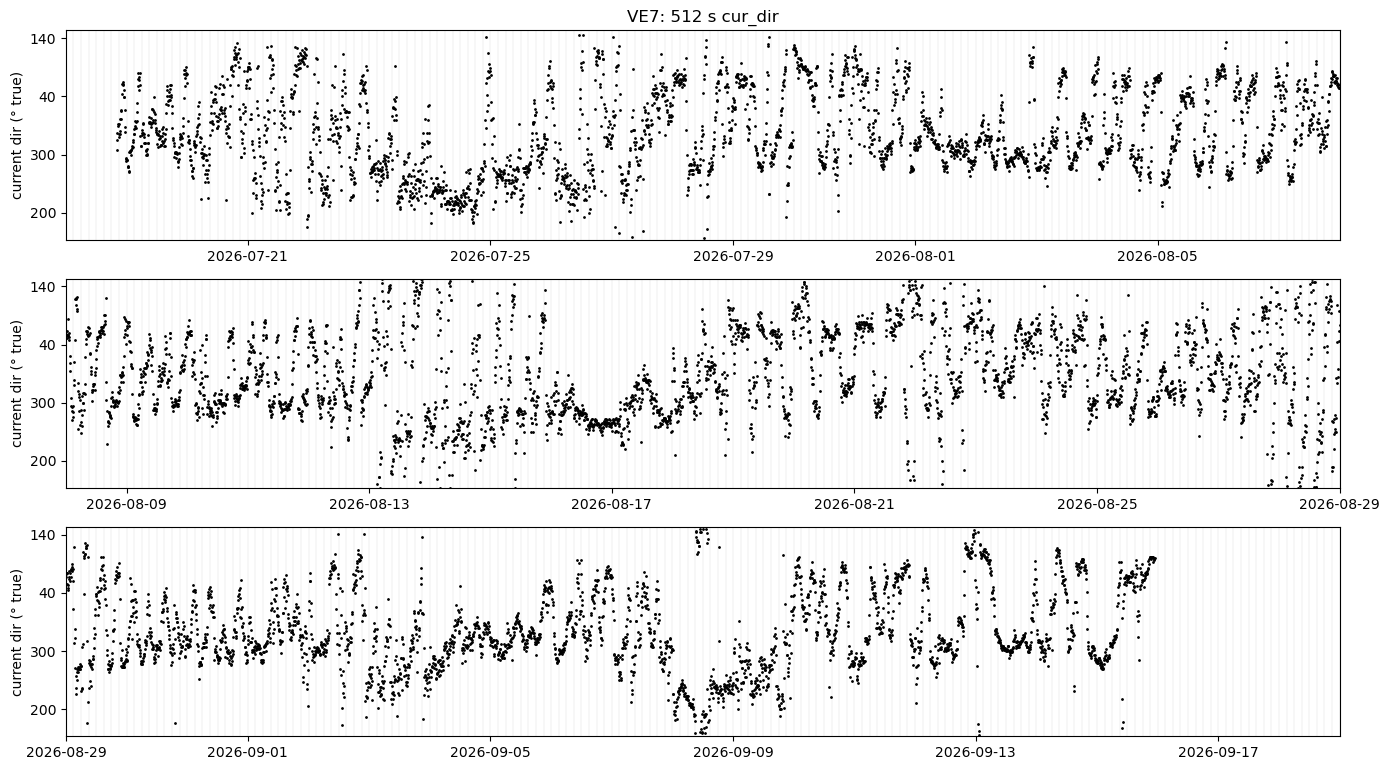

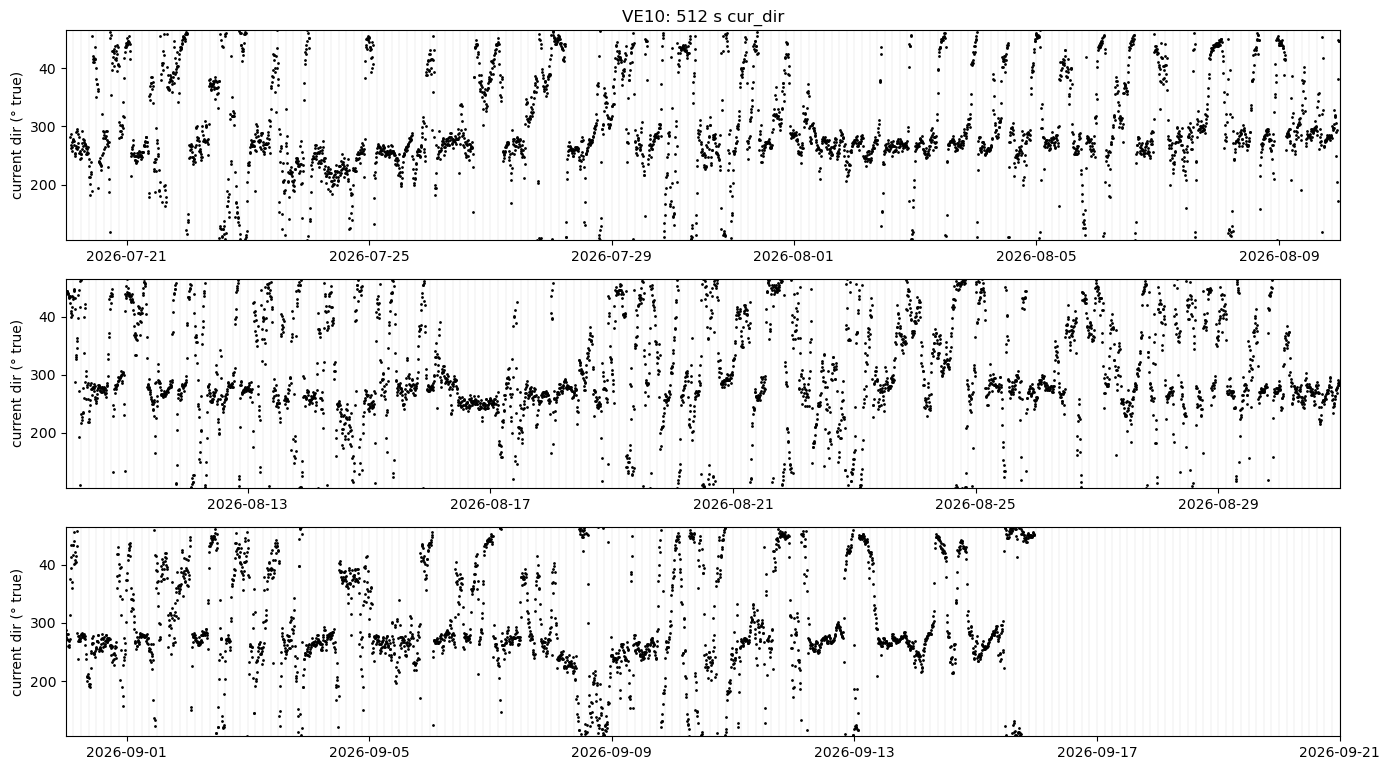

In [9]:
for S in SENSORS:
    plot_var(bulk[S], 'cur_dir', S, 'current dir (° true)')

### Wave direction (coming from, deg true)

In [7]:
for S in SENSORS:
    plot_var(bulk[S], 'wave_dir', S, 'wave dir (°)')

NameError: name 'plot_var' is not defined

### VE7 wave direction from 2026-08-01 to the end of the record

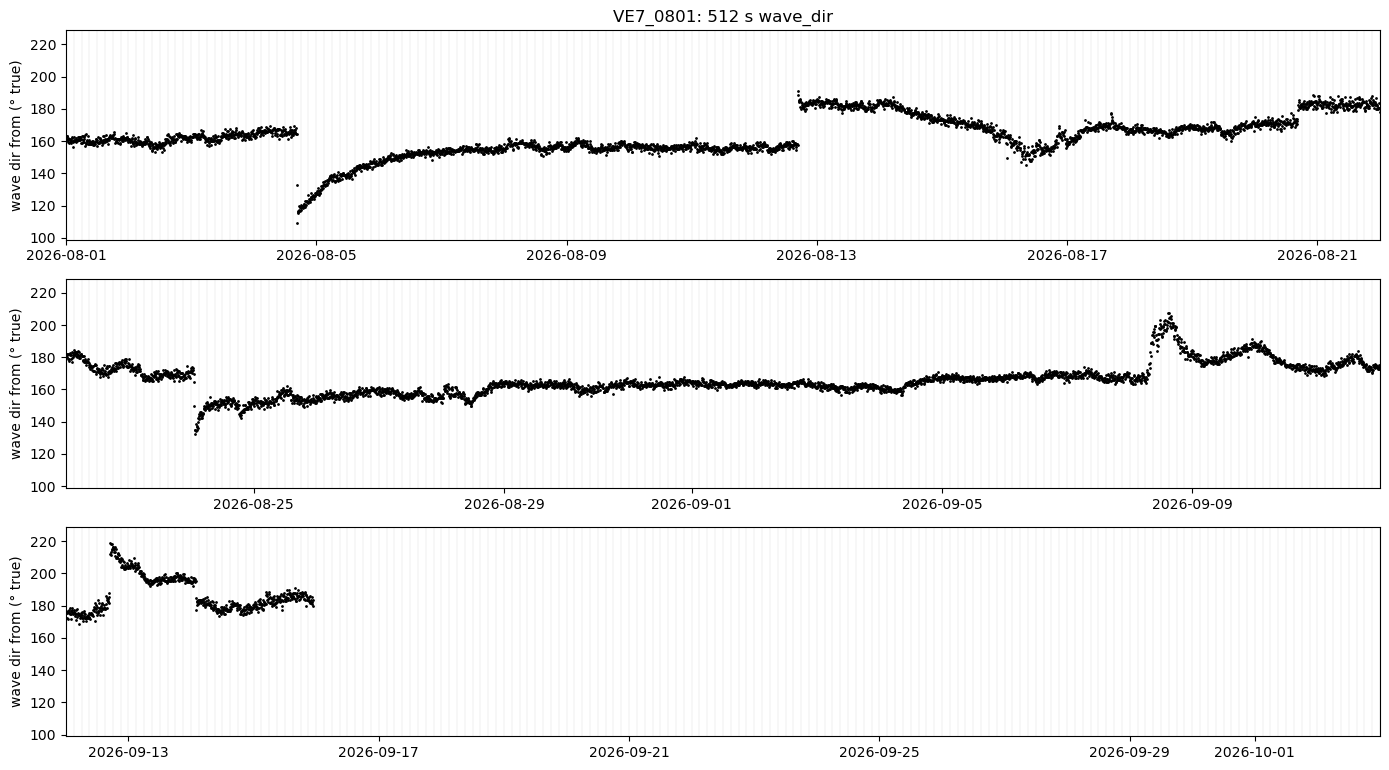

In [11]:
# Same plot, VE7 only, starting 2026-08-01. Saved as ADV_wave_dir512_VE7_0801.png.
plot_var(bulk['VE7']['2026-08-01':], 'wave_dir', 'VE7_0801', 'wave dir from (° true)')

### Wave direction difference: VE10 - VE7 and VE10 - VE4
Red = difference (left axis), wrapped to -180..180. Light lines = each sensor's wave direction (right axis). Waves refract between sensors, so a slowly varying offset is expected; sudden steps point at one sensor's head turning.

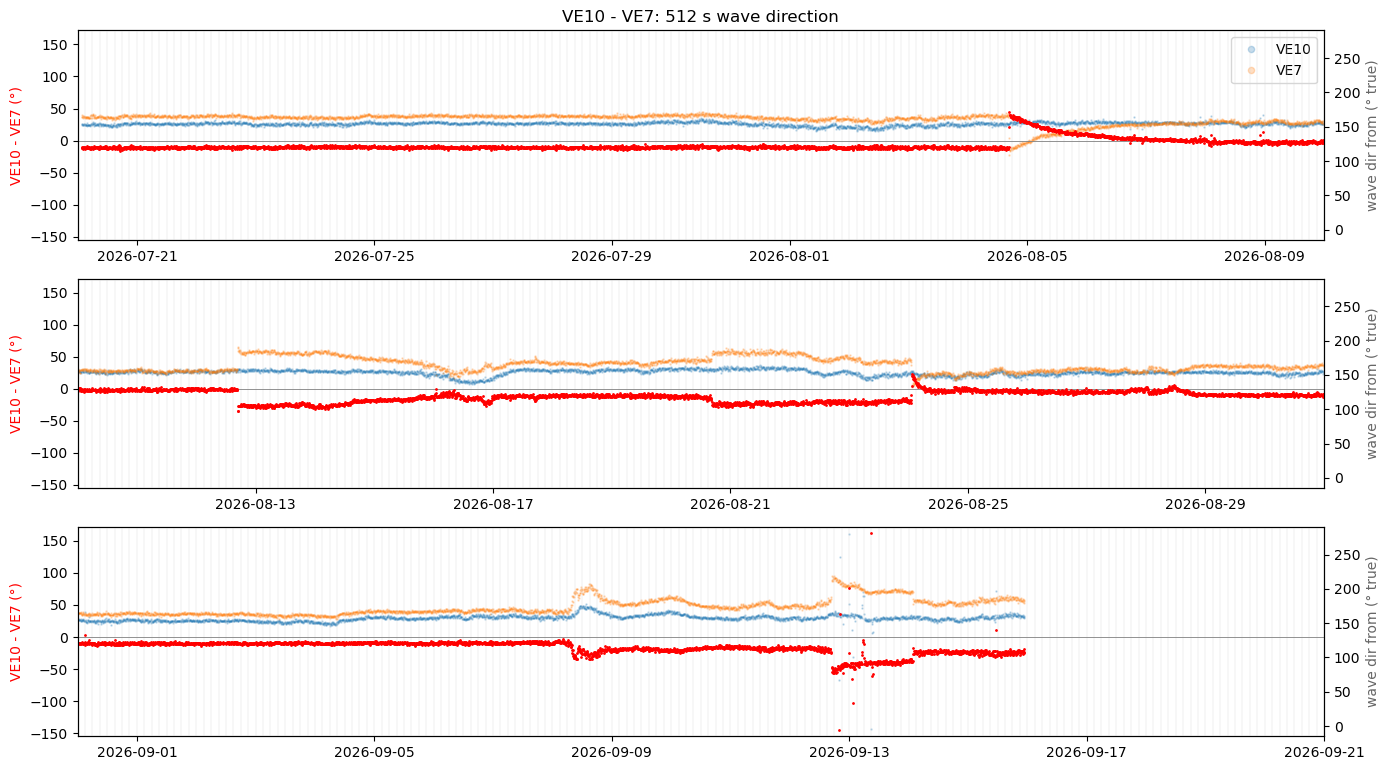

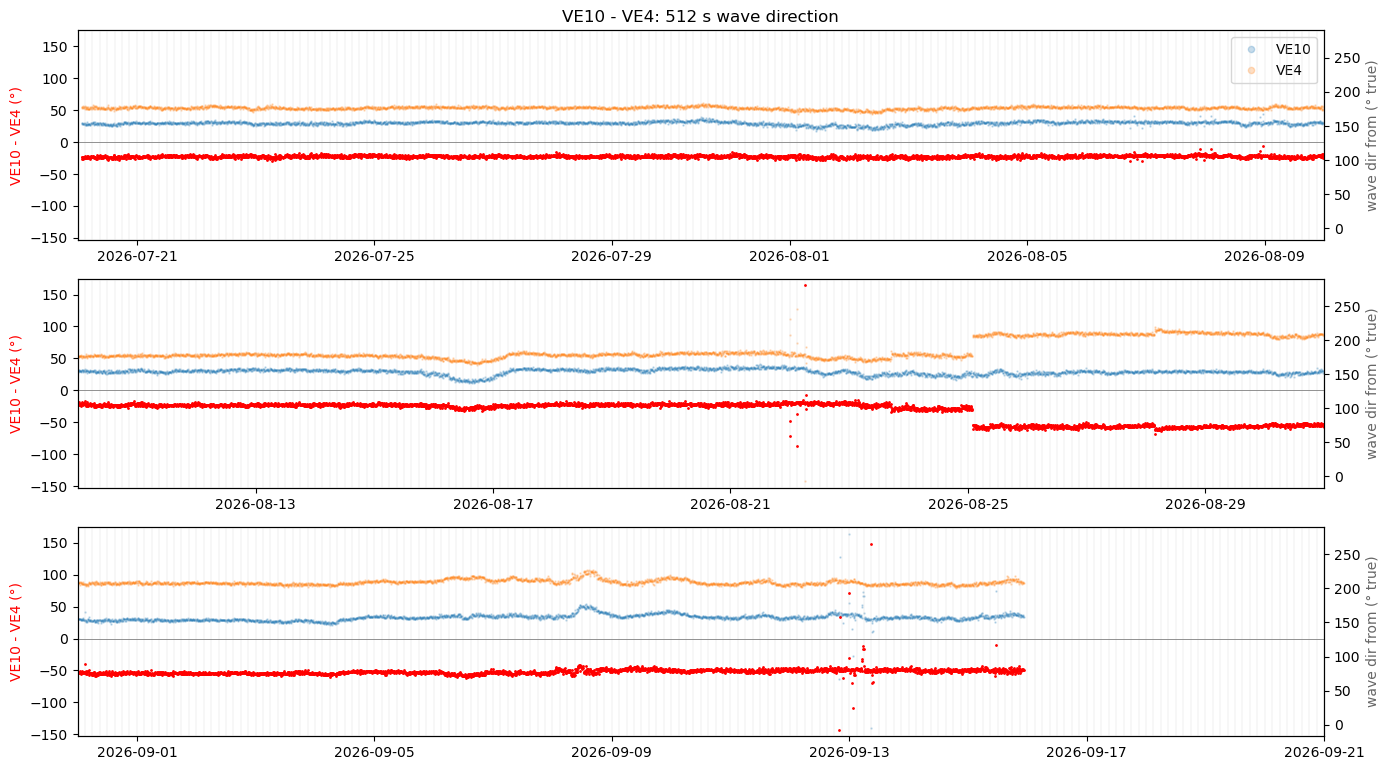

In [ ]:
def pair(a, b):
    """Wave direction of sensors a and b on the 512 s segments they share."""
    both = pd.concat([bulk[a].wave_dir, bulk[b].wave_dir], axis=1, keys=[a, b]).dropna()
    # keep directions near each other across 0/360: wrap both onto a's circular mean +/- 180
    r = np.radians(both[a])
    c = np.degrees(np.arctan2(np.sin(r).mean(), np.cos(r).mean())) % 360
    return (both - c + 180) % 360 - 180 + c


def plot_diff(a, b):
    """Difference a - b (red) with both wave directions overlaid lightly, 3-week panels."""
    both = pair(a, b)
    diff = (both[a] - both[b] + 180) % 360 - 180            # a - b, wrapped to +/-180

    start   = both.index[0].floor('D')
    n_panel = int(np.ceil((both.index[-1] - start) / PANEL))
    fig, axs = plt.subplots(n_panel, 1, figsize=(14, 2.6 * n_panel), squeeze=False)

    for i, ax in enumerate(axs[:, 0]):
        t0, t1 = start + i * PANEL, start + (i + 1) * PANEL
        for t in pd.date_range(t0, t1, freq=VLINE):          # vertical line every 3 h
            ax.axvline(t, lw=0.3, color='0.85', zorder=0)
        ax.axhline(0, lw=0.6, color='0.5')

        # right axis: the two wave directions, light
        ax2 = ax.twinx()
        d = both[t0:t1]
        ax2.plot(d.index, d[a], '.', ms=1.5, color='tab:blue',   alpha=0.25, label=a)
        ax2.plot(d.index, d[b], '.', ms=1.5, color='tab:orange', alpha=0.25, label=b)
        ax2.set_ylim(both.min().min() - 10, both.max().max() + 10)
        ax2.yaxis.set_major_formatter(lambda val, pos: f'{val % 360:.0f}')   # label ticks 0-360
        ax2.set_ylabel('wave dir from (° true)', color='0.4')

        # left axis: the difference, red, drawn on top of the light directions
        ax.plot(diff[t0:t1].index, diff[t0:t1], '.', ms=2, color='r')
        ax.set_ylim(diff.min() - 10, diff.max() + 10)
        ax.set_ylabel(f'{a} - {b} (°)', color='r')
        ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)  # red in front
        ax.set_xlim(t0, t1)

    axs[0, 0].set_title(f'{a} - {b}: 512 s wave direction')
    ax2_first = axs[0, 0].figure.axes[n_panel]                 # right axis of the first panel
    ax2_first.legend(loc='upper right', markerscale=6)
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/ADV_wave_dir_diff512_{a}-{b}.png', dpi=150)
    plt.show()


for other in ['VE7', 'VE4']:
    plot_diff('VE10', other)

### Scatter: VE10 vs VE7 and VE10 vs VE4 wave direction

In [2]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for ax, other in zip(axs, ['VE7', 'VE4']):
    both = pair('VE10', other)                              # common segments, wrapped together
    ax.plot(both['VE10'], both[other], '.', ms=2, color='k')
    lo, hi = 100, 240                                       # zoom on the main cluster [deg]
    ax.plot([lo, hi], [lo, hi], color='r', lw=0.8)          # 1:1 line
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
    ax.grid(lw=0.4, color='0.85')
    ax.set_xlabel('VE10 wave dir from (° true)')
    ax.set_ylabel(f'{other} wave dir from (° true)')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ADV_wave_dir512_scatter_VE10.png', dpi=150)
plt.show()

NameError: name 'plt' is not defined